In [1]:
from pyrokinetics import Pyro, PyroScan
from pathlib import Path
import os
import numpy as np
import copy

In [2]:
Files_to_read = ["p2_mtm15", "p3_mtm17", "p1_ball9"]

In [3]:
root_location = Path("/mnt/data/Downloads/zenodo/linear/cgyro/coll/")

gyro_dict = {
    "p2_mtm15" : root_location / "nue030_sh07/n25",
    "p3_mtm17" : root_location / "nue030_sh07/n20",
    "p1_ball9" : root_location / "nue030_sh07/n35",
}
cgyro_dict ={
}
for file in Files_to_read:
    cgyro_pyro = Pyro(gk_file = gyro_dict[file] / "input.cgyro")
    cgyro_pyro.load_gk_output()
    cgyro_dict[file] = cgyro_pyro


In [4]:
GYRO_DIR = Path("/mnt/data/Gyrokinetic_Simulations/")
gftm_dict = {
    "p2_mtm15" : GYRO_DIR / "GFTM/Runs/MTM_NXW_SCAN/P2_mtm15",
    "p3_mtm17" : GYRO_DIR / "GFTM/Runs/MTM_NXW_SCAN/P3_mtm17",
    "p1_ball9" : GYRO_DIR / "GFTM/Runs/MTM_NXW_SCAN/P1_ball9",
}

for file in Files_to_read:
    gftm_pyro_scan = gftm_dict[file] / "pyroscan.json"
    gftm_pyro_scan_netcdf = gftm_dict[file] / "pyroscan.nc"
    gftm_pyroscan = PyroScan(
                        pyroscan_json=gftm_pyro_scan,
                        load_base_pyro=True,
                    )
    gftm_pyroscan.load_gk_output(
                            netcdf_file=gftm_pyro_scan_netcdf
                        )
    gftm_dict[file] = gftm_pyroscan



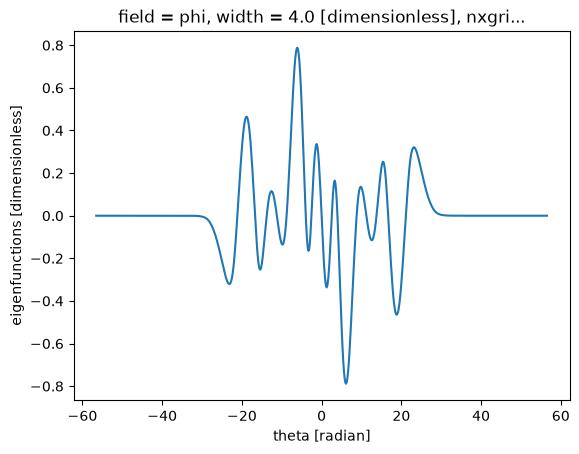

In [5]:
np.real(gftm_pyroscan.gk_output["eigenfunctions"].isel(mode = 0).sel(field = "phi").isel(width = 3).isel(nxgrid = 3)).plot()

In [6]:
def calculate_eigenfunction_properties(da):
    positive_theta = da.where(da.theta > 0, drop=True).squeeze(drop=True)
    negative_theta = da.where(da.theta < 0, drop=True).squeeze(drop=True)
    positive_sum = positive_theta.sum(dim="theta").squeeze(drop=True)
    negative_sum = negative_theta.sum(dim="theta").squeeze(drop=True)
    positive_sum = positive_sum.item()
    negative_sum = negative_sum.item()
    func_odd = (positive_sum * negative_sum < 0)
    neg = (func_odd and positive_sum < 0) or (not func_odd and positive_sum > 0)
    average_amplitude = ((np.abs(positive_sum) + np.abs(negative_sum)) / 2)
    return func_odd, neg, average_amplitude

def compare_eigenfunctions(da1, da2):
    func_odd_1, neg_1, average_amplitude_1 = calculate_eigenfunction_properties(da1)
    func_odd_2, neg_2, average_amplitude_2 = calculate_eigenfunction_properties(da2)
    
    if func_odd_1 != func_odd_2:
        return False
    if neg_1 != neg_2:
        return False
    if np.abs(average_amplitude_1 - average_amplitude_2) > (average_amplitude_1 + average_amplitude_2)/5:
        return False
    return True




(np.False_, np.True_, <Quantity(106.67502262514381, 'dimensionless')>)
(np.True_, np.True_, <Quantity(7.199725001147661, 'dimensionless')>)


False

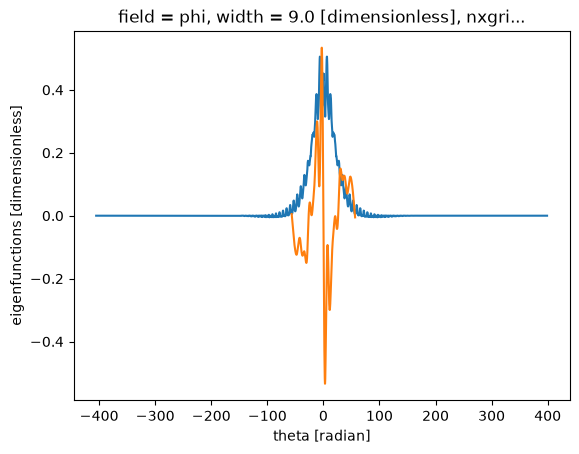

In [7]:
cgyro_eigenfunction = np.real(cgyro_pyro.gk_output["eigenfunctions"].sel(field = "phi").isel(time=-1))
gftm_eigenfunction = np.real(gftm_pyroscan.gk_output["eigenfunctions"].isel(mode = 0).sel(field = "phi").isel(width = 5).isel(nxgrid = 4))
print(calculate_eigenfunction_properties(cgyro_eigenfunction))
print(calculate_eigenfunction_properties(gftm_eigenfunction))
cgyro_eigenfunction.plot()
gftm_eigenfunction.plot()

compare_eigenfunctions(cgyro_eigenfunction, gftm_eigenfunction)

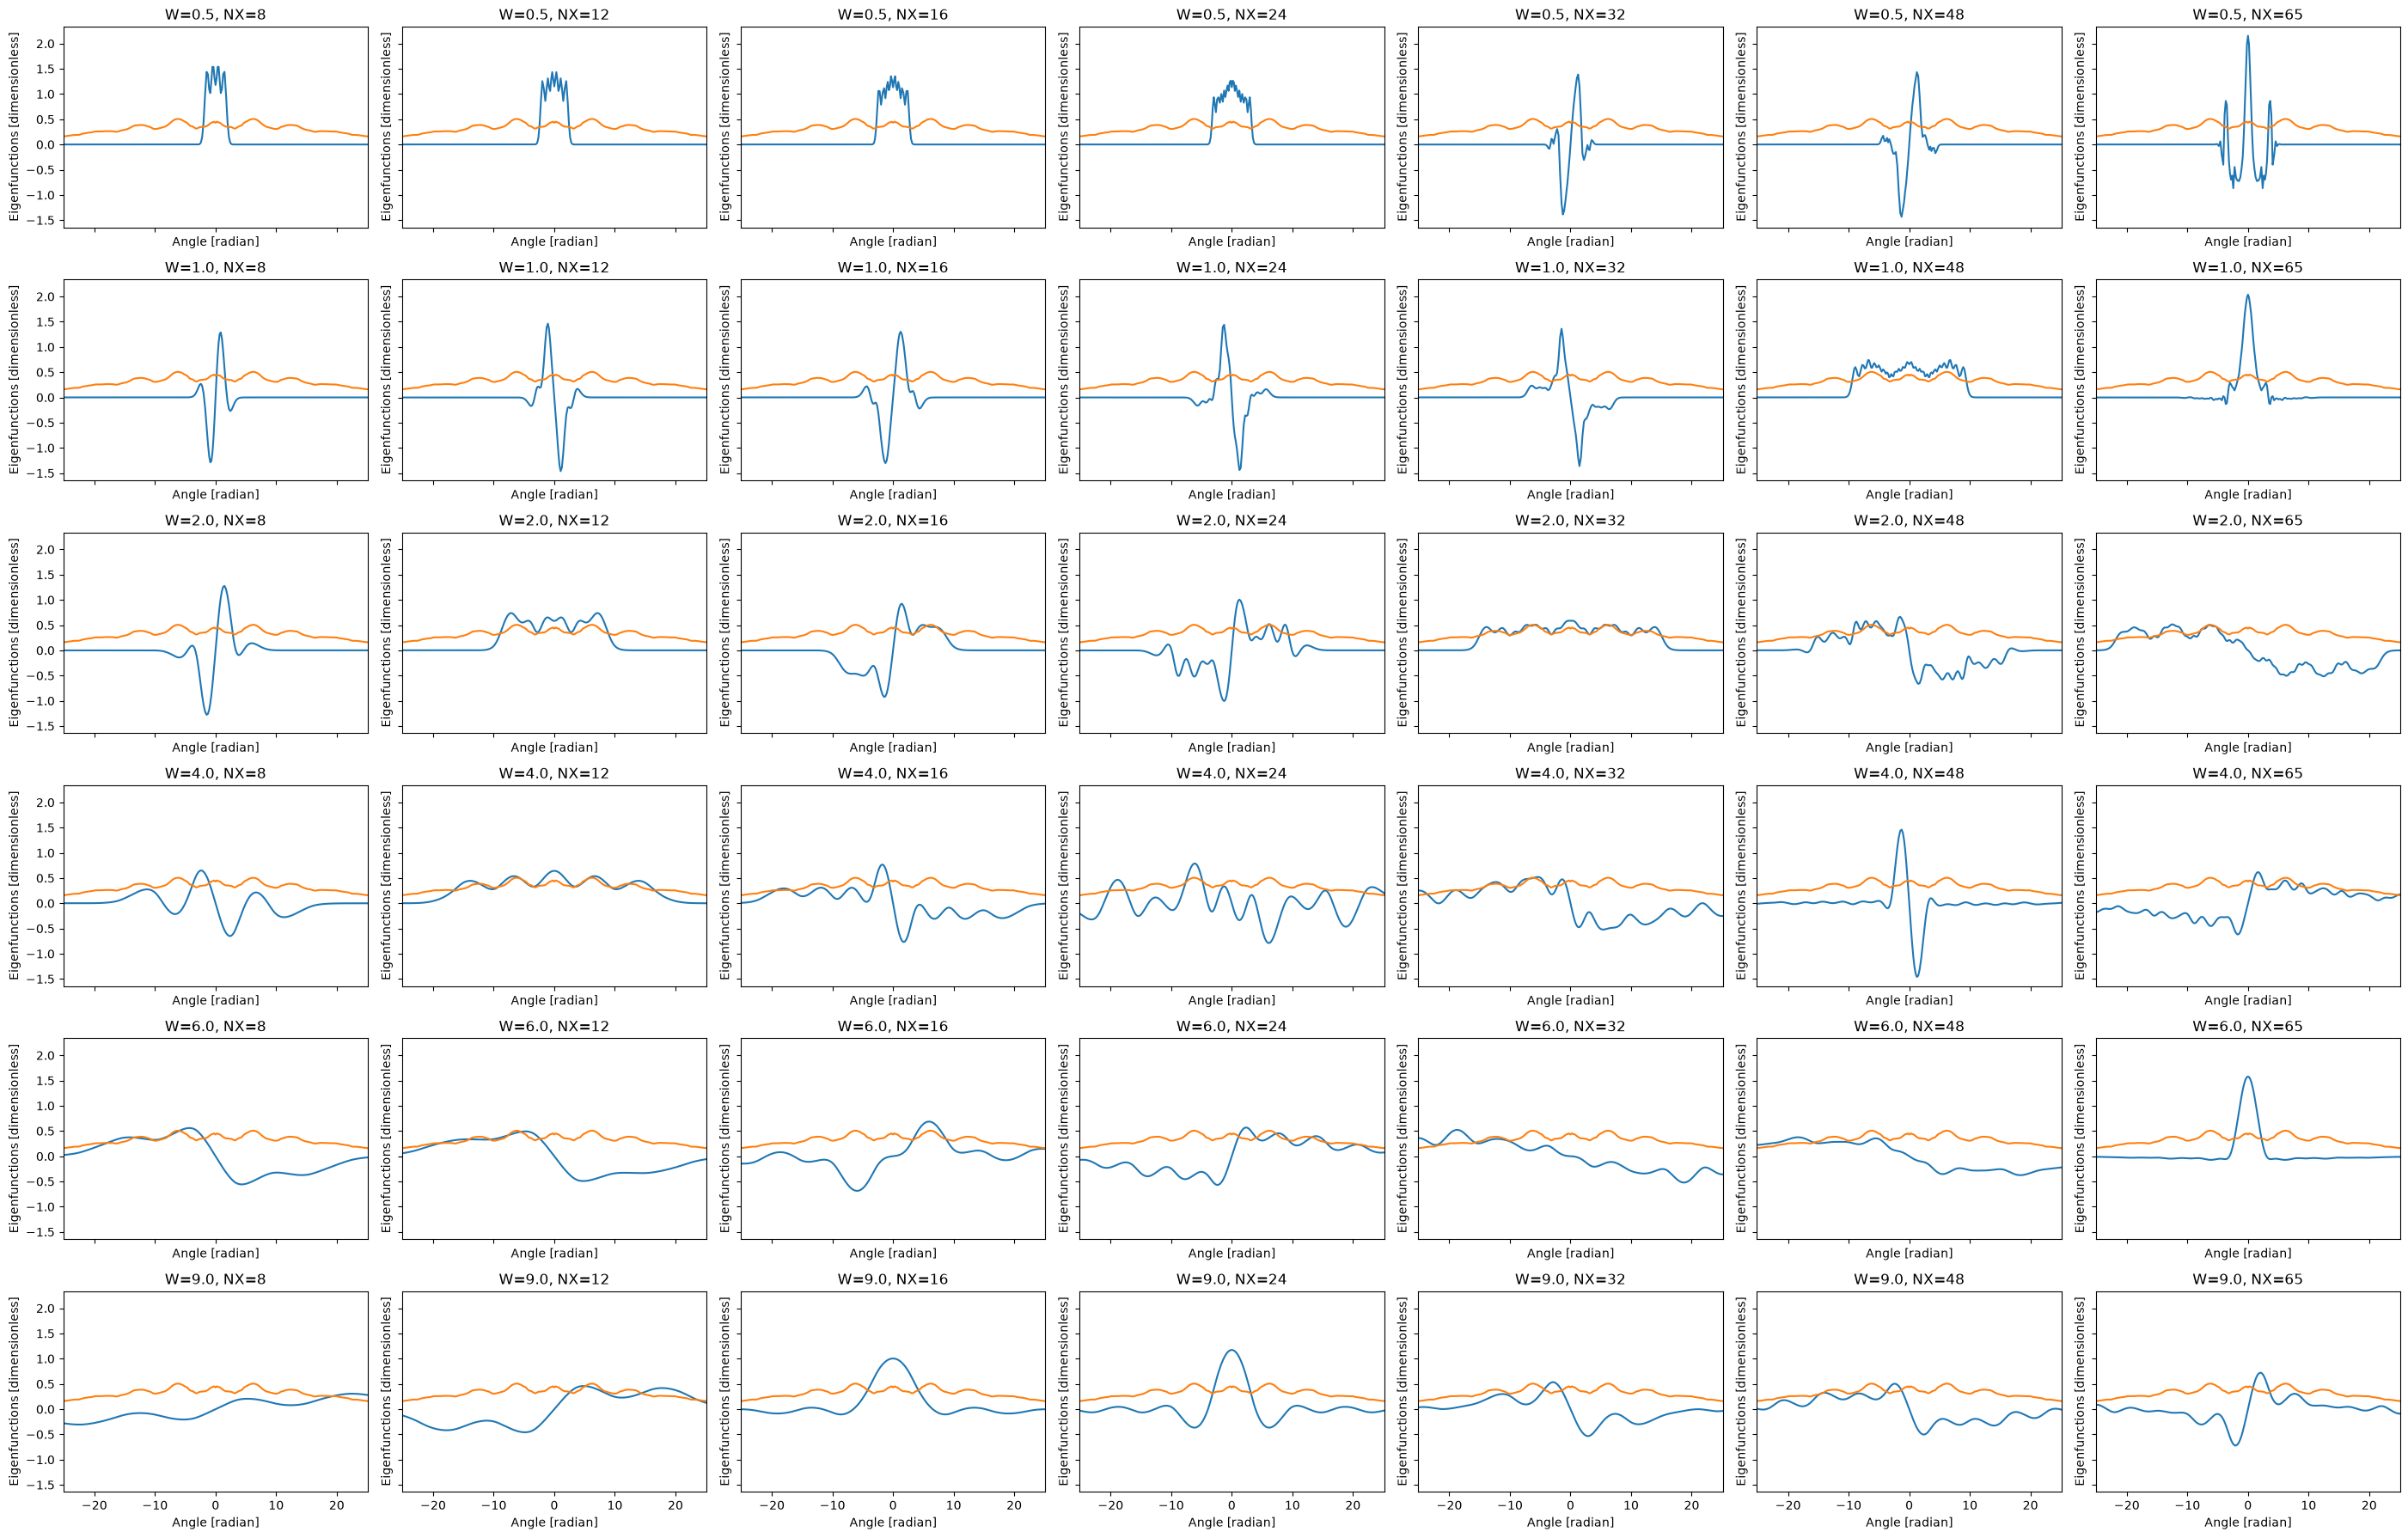

In [8]:
import matplotlib.pyplot as plt
import numpy as np

eigenfunctions = gftm_pyroscan.gk_output["eigenfunctions"]
cgyro_eigenfunctions= np.real(cgyro_pyro.gk_output["eigenfunctions"].sel(field = "phi").isel(time=-1))

widths = eigenfunctions.width.values
nxgrids = eigenfunctions.nxgrid.values

fig, axes = plt.subplots(
    len(widths),
    len(nxgrids),
    figsize=(4 * len(nxgrids), 3 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):

        ax = axes[i, j]

        phi_gftm = np.real(
            eigenfunctions
            .sel(width=width, nxgrid=nxgrid, field="phi")
            .isel(mode=0)
        )

        phi_gftm.plot(ax=ax)
        cgyro_eigenfunctions.plot(ax=ax)

        ax.set_title(f"W={width}, NX={nxgrid}")
        ax.set_xlim(-8*np.pi, 8*np.pi)  # Set x-axis limits to -3π to 3π

plt.tight_layout()
plt.show()

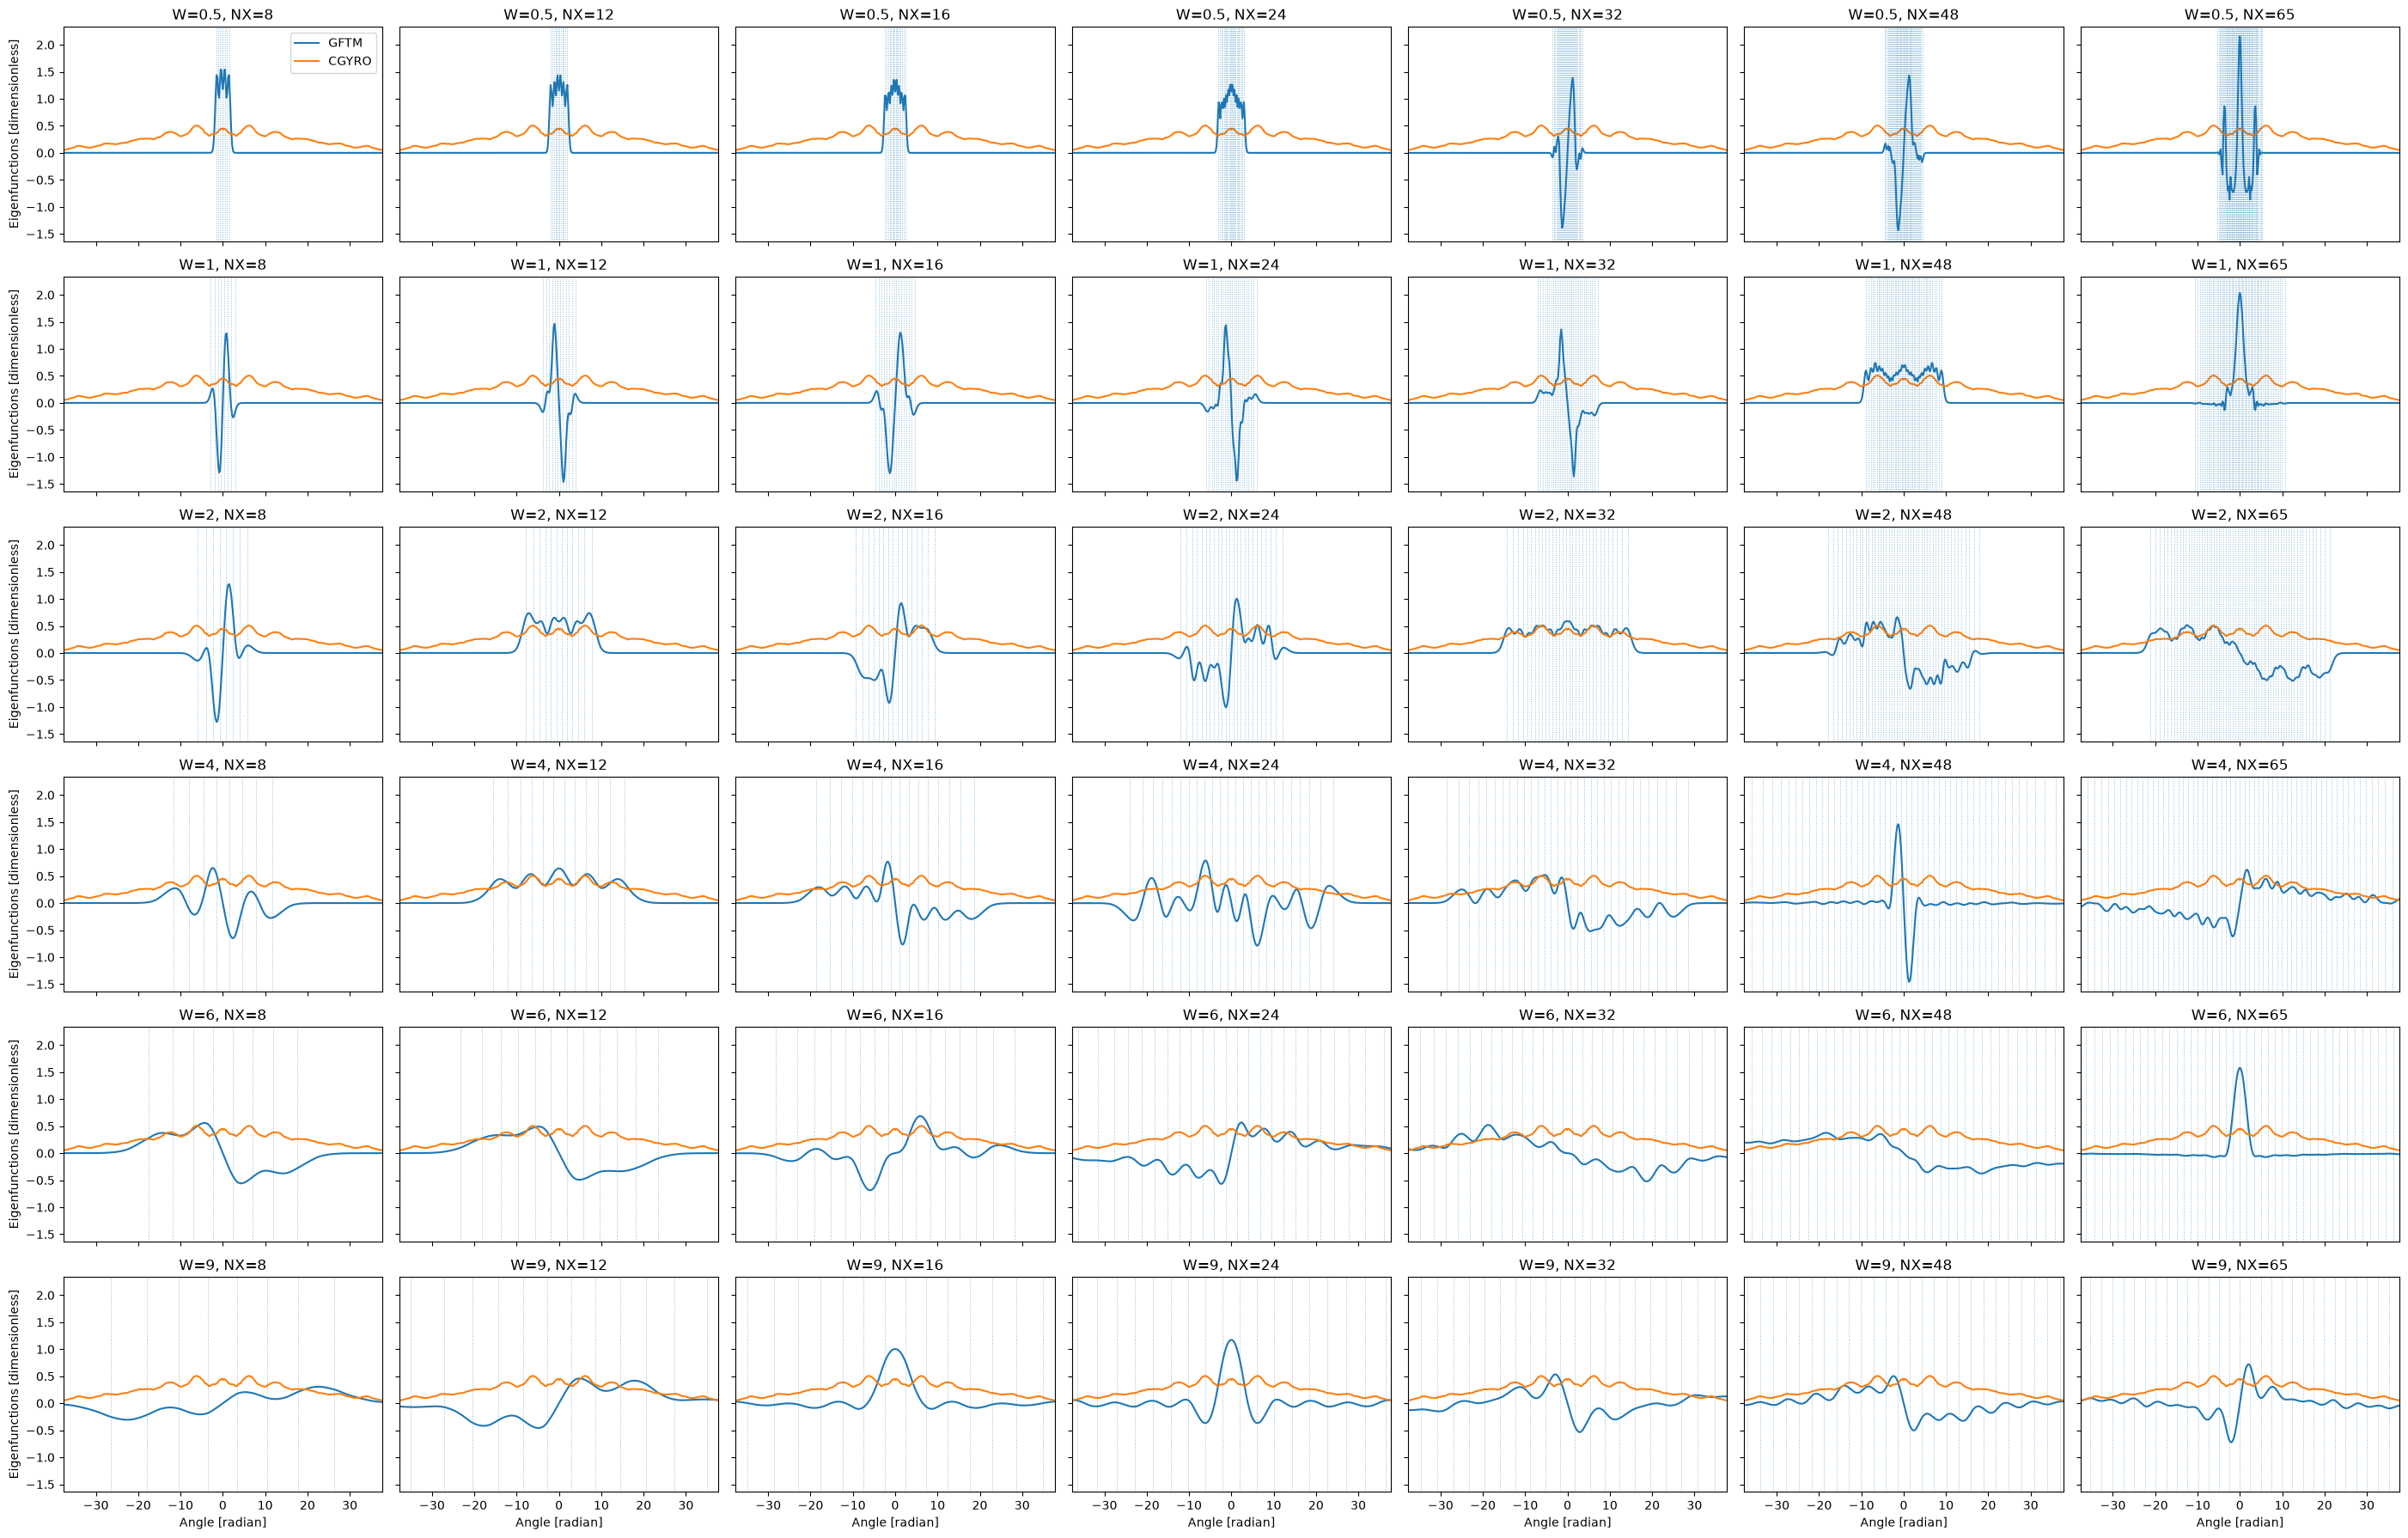

In [9]:
import matplotlib.pyplot as plt
import numpy as np


from scipy.special import roots_hermite

def gaussian_quadrature_points(width, nxgrid):
    # Gauss-Hermite nodes and weights
    nodes, weights = roots_hermite(int(nxgrid))

    # Scale to the physical theta coordinate
    theta_nodes = width * nodes

    return theta_nodes, weights


eigenfunctions = gftm_pyroscan.gk_output["eigenfunctions"]

cgyro_eigenfunction = np.real(
    cgyro_pyro.gk_output["eigenfunctions"]
    .sel(field="phi")
    .isel(time=-1)
    .squeeze(drop=True)
)

widths = eigenfunctions.coords["width"].values
nxgrids = eigenfunctions.coords["nxgrid"].values

fig, axes = plt.subplots(
    nrows=len(widths),
    ncols=len(nxgrids),
    figsize=(4 * len(nxgrids), 3 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):
        ax = axes[i, j]

        phi_gftm = np.real(
            eigenfunctions
            .sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
            .isel(mode=0)
            .squeeze(drop=True)
        )

        # Plot the two eigenfunctions
        phi_gftm.plot(
            ax=ax,
            label="GFTM",
        )

        cgyro_eigenfunction.plot(
            ax=ax,
            label="CGYRO",
        )

        # Calculate the Gauss-Hermite quadrature locations
        theta_nodes, quadrature_weights = gaussian_quadrature_points(
            width=width,
            nxgrid=nxgrid,
        )

        # Draw one vertical line at each quadrature point
        for theta_node in theta_nodes:
            ax.axvline(
                theta_node,
                linestyle=":",
                linewidth=0.7,
                alpha=0.5,
            )

        ax.set_title(f"W={width:g}, NX={nxgrid}")
        ax.set_xlim(-12 * np.pi, 12 * np.pi)

        # Avoid repeated xarray-generated axis labels
        if i < len(widths) - 1:
            ax.set_xlabel("")

        if j > 0:
            ax.set_ylabel("")

# Put a legend only on the first subplot
axes[0, 0].legend()

fig.tight_layout()
plt.show()

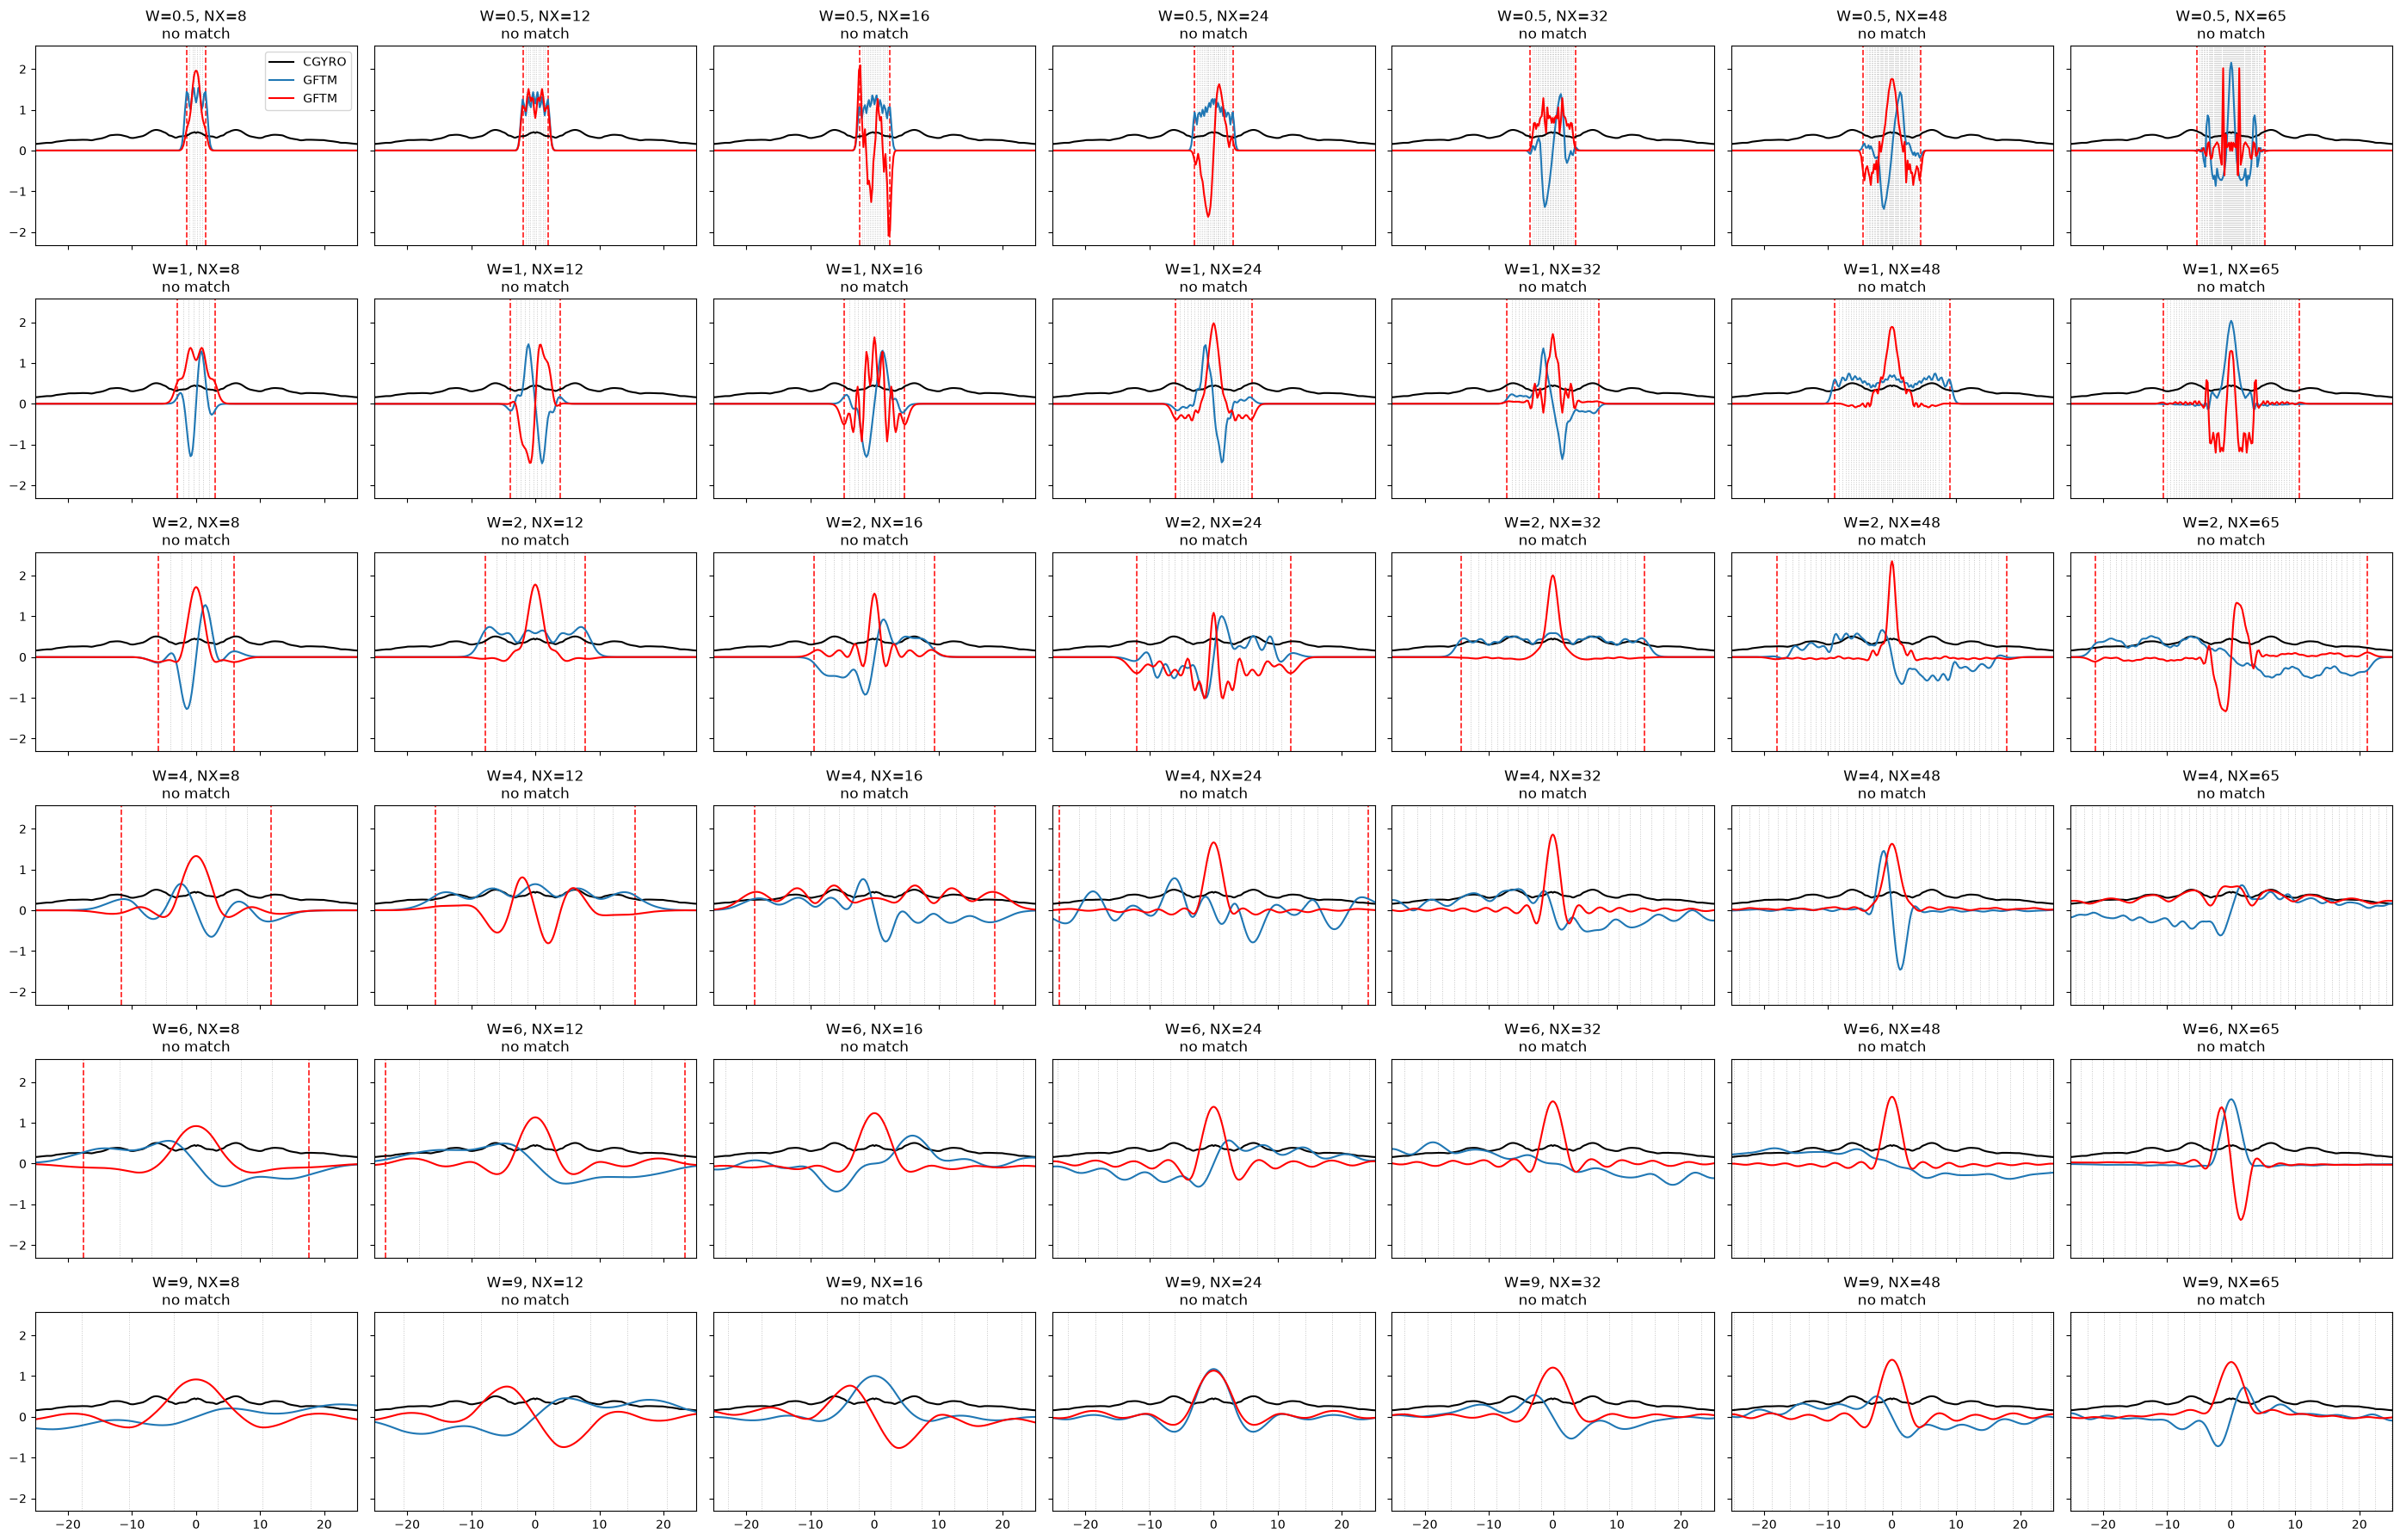

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite


def calculate_eigenfunction_properties(da):
    da = da.squeeze(drop=True)

    positive_theta = da.where(da.theta > 0, drop=True)
    negative_theta = da.where(da.theta < 0, drop=True)

    positive_sum = positive_theta.sum(dim="theta").item()
    negative_sum = negative_theta.sum(dim="theta").item()

    func_odd = positive_sum * negative_sum < 0

    neg = (
        (func_odd and positive_sum < 0)
        or
        ((not func_odd) and positive_sum > 0)
    )

    average_amplitude = (
        np.abs(positive_sum) + np.abs(negative_sum)
    ) / 2

    return func_odd, neg, average_amplitude


def compare_eigenfunctions(da1, da2):
    (
        func_odd_1,
        neg_1,
        average_amplitude_1,
    ) = calculate_eigenfunction_properties(da1)

    (
        func_odd_2,
        neg_2,
        average_amplitude_2,
    ) = calculate_eigenfunction_properties(da2)

    if func_odd_1 != func_odd_2:
        return False

    if neg_1 != neg_2:
        return False

    amplitude_difference = np.abs(
        average_amplitude_1 - average_amplitude_2
    )

    amplitude_tolerance = (
        average_amplitude_1 + average_amplitude_2
    ) / 10

    if amplitude_difference > amplitude_tolerance:
        return False

    return True


def gaussian_quadrature_points(width, nxgrid):
    """
    Return Gauss-Hermite quadrature points in theta.

    The dimensionless nodes returned by roots_hermite use the
    exp(-x**2) weighting. GFTM theta coordinates are obtained using

        theta = width * x
    """
    nodes, weights = roots_hermite(int(nxgrid))
    theta_nodes = width * nodes

    return theta_nodes, weights


eigenfunctions = gftm_pyroscan.gk_output["eigenfunctions"]

cgyro_eigenfunction = np.real(
    cgyro_pyro.gk_output["eigenfunctions"]
    .sel(field="phi")
    .isel(time=-1)
    .squeeze(drop=True)
)

widths = eigenfunctions.coords["width"].values
nxgrids = eigenfunctions.coords["nxgrid"].values

fig, axes = plt.subplots(
    nrows=len(widths),
    ncols=len(nxgrids),
    figsize=(4 * len(nxgrids), 3 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

theta_min = -8 * np.pi
theta_max = 8 * np.pi

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):
        ax = axes[i, j]

        phi_gftm = np.real(
            eigenfunctions
            .sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
            .isel(mode=0)
            .squeeze(drop=True)
        )
        phi_gftm_sub = np.real(
            eigenfunctions
            .sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
            .isel(mode=2)
            .squeeze(drop=True)
        )

        # Test whether this GFTM eigenfunction agrees with CGYRO
        agrees = compare_eigenfunctions(
            cgyro_eigenfunction,
            phi_gftm,
        )

        gftm_colour = "green" if agrees else "C0"

        # Plot the CGYRO reference eigenfunction
        ax.plot(
            cgyro_eigenfunction.theta,
            cgyro_eigenfunction,
            color="black",
            linewidth=1.5,
            label="CGYRO",
        )

        # Plot GFTM, green when it satisfies the comparison
        ax.plot(
            phi_gftm.theta,
            phi_gftm,
            color=gftm_colour,
            linewidth=1.5,
            label="GFTM",
        )

        ax.plot(
            phi_gftm.theta,
            phi_gftm_sub,
            color="red",
            linewidth=1.5,
            label="GFTM",
        )

        theta_nodes, quadrature_weights = (
            gaussian_quadrature_points(
                width=width,
                nxgrid=nxgrid,
            )
        )

        # Draw all interior nodes
        for theta_node in theta_nodes[1:-1]:
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="grey",
                    linestyle=":",
                    linewidth=0.7,
                    alpha=0.45,
                    zorder=0,
                )

        # Highlight the two outermost nodes
        outer_nodes = [theta_nodes[0], theta_nodes[-1]]

        for theta_node in outer_nodes:
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="red",
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.9,
                    zorder=1,
                )

        match_text = "match" if agrees else "no match"

        ax.set_title(
            f"W={width:g}, NX={int(nxgrid)}\n"
            f"{match_text}"
        )

        ax.set_xlim(theta_min, theta_max)

        if i < len(widths) - 1:
            ax.set_xlabel("")

        if j > 0:
            ax.set_ylabel("")

axes[0, 0].legend()

fig.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite

def calculate_eigenfunction_properties(da):
    da = da.squeeze(drop=True)

    positive_theta = da.where(da.theta > 0, drop=True)
    negative_theta = da.where(da.theta < 0, drop=True)

    positive_sum = positive_theta.sum(dim="theta").item()
    negative_sum = negative_theta.sum(dim="theta").item()

    func_odd = positive_sum * negative_sum < 0

    neg = (
        (func_odd and positive_sum < 0)
        or
        ((not func_odd) and positive_sum > 0)
    )

    average_amplitude = (
        np.abs(positive_sum) + np.abs(negative_sum)
    ) / 2

    return func_odd, neg, average_amplitude

def compare_eigenfunctions(da1, da2):
    (
        func_odd_1,
        neg_1,
        average_amplitude_1,
    ) = calculate_eigenfunction_properties(da1)

    (
        func_odd_2,
        neg_2,
        average_amplitude_2,
    ) = calculate_eigenfunction_properties(da2)

    if func_odd_1 != func_odd_2:
        return False

    if neg_1 != neg_2:
        return False

    amplitude_difference = np.abs(
        average_amplitude_1 - average_amplitude_2
    )

    amplitude_tolerance = (
        average_amplitude_1 + average_amplitude_2
    ) / 10

    if amplitude_difference > amplitude_tolerance:
        return False

    return True


def gaussian_quadrature_points(width, nxgrid):
    """Return Gauss-Hermite nodes in the physical theta coordinate."""
    nodes, weights = roots_hermite(int(nxgrid))
    theta_nodes = width * nodes

    return theta_nodes, weights


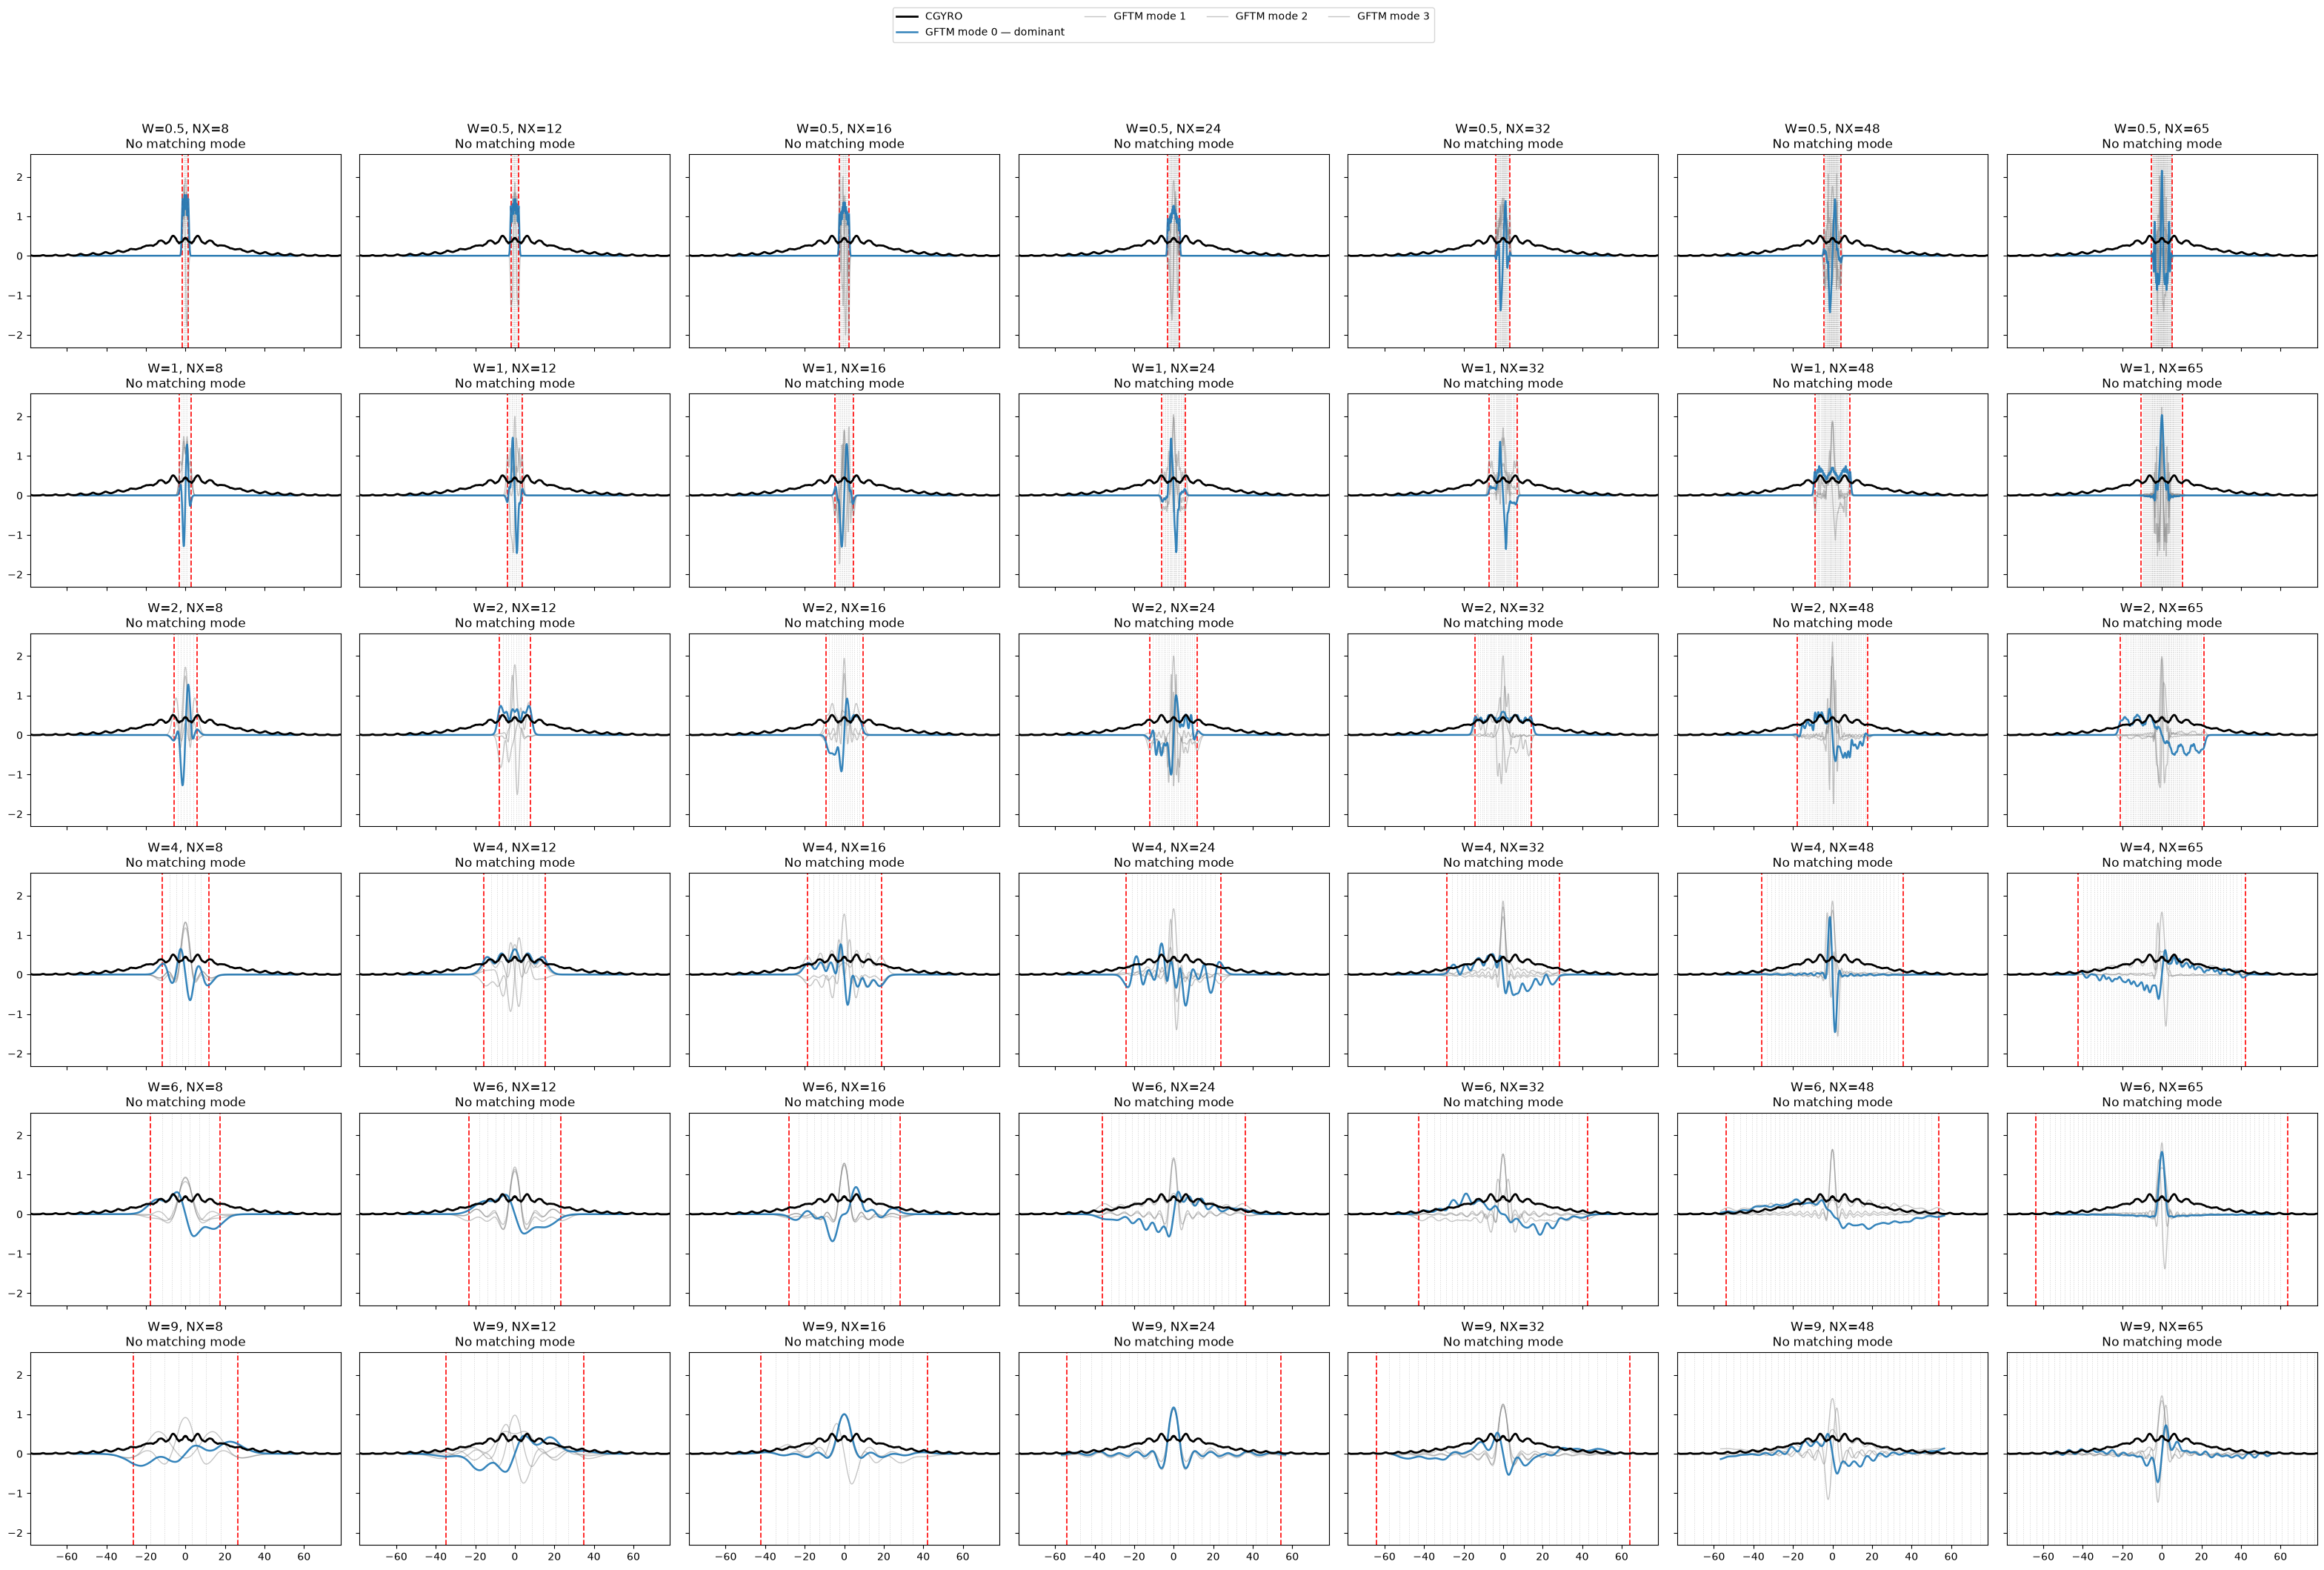

In [12]:

gftm_pyroscan = gftm_dict["p1_ball9"]
cgyro_pyro = cgyro_dict["p1_ball9"]

eigenfunctions = gftm_pyroscan.gk_output["eigenfunctions"]

cgyro_eigenfunction = np.real(
    cgyro_pyro.gk_output["eigenfunctions"]
    .sel(field="phi")
    .isel(time=-1)
    .squeeze(drop=True)
)

widths = eigenfunctions.coords["width"].values
nxgrids = eigenfunctions.coords["nxgrid"].values
mode_values = eigenfunctions.coords["mode"].values

fig, axes = plt.subplots(
    nrows=len(widths),
    ncols=len(nxgrids),
    figsize=(4.5 * len(nxgrids), 3.5 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

theta_min = -25 * np.pi
theta_max = 25 * np.pi

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):
        ax = axes[i, j]

        local_modes = np.real(
            eigenfunctions.sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
        )

        # Plot the CGYRO reference
        ax.plot(
            cgyro_eigenfunction.theta,
            cgyro_eigenfunction,
            color="black",
            linewidth=2.0,
            label="CGYRO",
            zorder=5,
        )

        matching_modes = []

        # Test and plot every GFTM mode
        for mode_index, mode_value in enumerate(mode_values):
            phi_gftm = (
                local_modes
                .isel(mode=mode_index)
                .squeeze(drop=True)
            )

            agrees = compare_eigenfunctions(
                cgyro_eigenfunction,
                phi_gftm,
            )

            if agrees:
                matching_modes.append(mode_value)

                colour = "green"
                linewidth = 2.5
                alpha = 1.0
                zorder = 4
                label = f"GFTM mode {mode_value} — match"

            elif mode_index == 0:
                # Dominant mode, but not a match
                colour = "C0"
                linewidth = 1.8
                alpha = 0.9
                zorder = 3
                label = f"GFTM mode {mode_value} — dominant"

            else:
                # Nonmatching subdominant mode
                colour = "grey"
                linewidth = 1.0
                alpha = 0.45
                zorder = 2
                label = f"GFTM mode {mode_value}"

            ax.plot(
                phi_gftm.theta,
                phi_gftm,
                color=colour,
                linewidth=linewidth,
                alpha=alpha,
                label=label,
                zorder=zorder,
            )

        # Gauss-Hermite quadrature nodes
        theta_nodes, quadrature_weights = (
            gaussian_quadrature_points(
                width=width,
                nxgrid=nxgrid,
            )
        )

        # Interior nodes
        for theta_node in theta_nodes[1:-1]:
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="grey",
                    linestyle=":",
                    linewidth=0.7,
                    alpha=0.35,
                    zorder=0,
                )

        # Outermost nodes
        for theta_node in (theta_nodes[0], theta_nodes[-1]):
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="red",
                    linestyle="--",
                    linewidth=1.3,
                    alpha=0.9,
                    zorder=1,
                )

        if matching_modes:
            matched_text = ", ".join(
                str(mode) for mode in matching_modes
            )
            match_text = f"Matching mode(s): {matched_text}"
        else:
            match_text = "No matching mode"

        ax.set_title(
            f"W={width:g}, NX={int(nxgrid)}\n"
            f"{match_text}"
        )

        ax.set_xlim(theta_min, theta_max)

        if i < len(widths) - 1:
            ax.set_xlabel("")

        if j > 0:
            ax.set_ylabel("")

# This may become large if there are many modes, so place it outside
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=min(len(labels), 4),
)

fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Proje

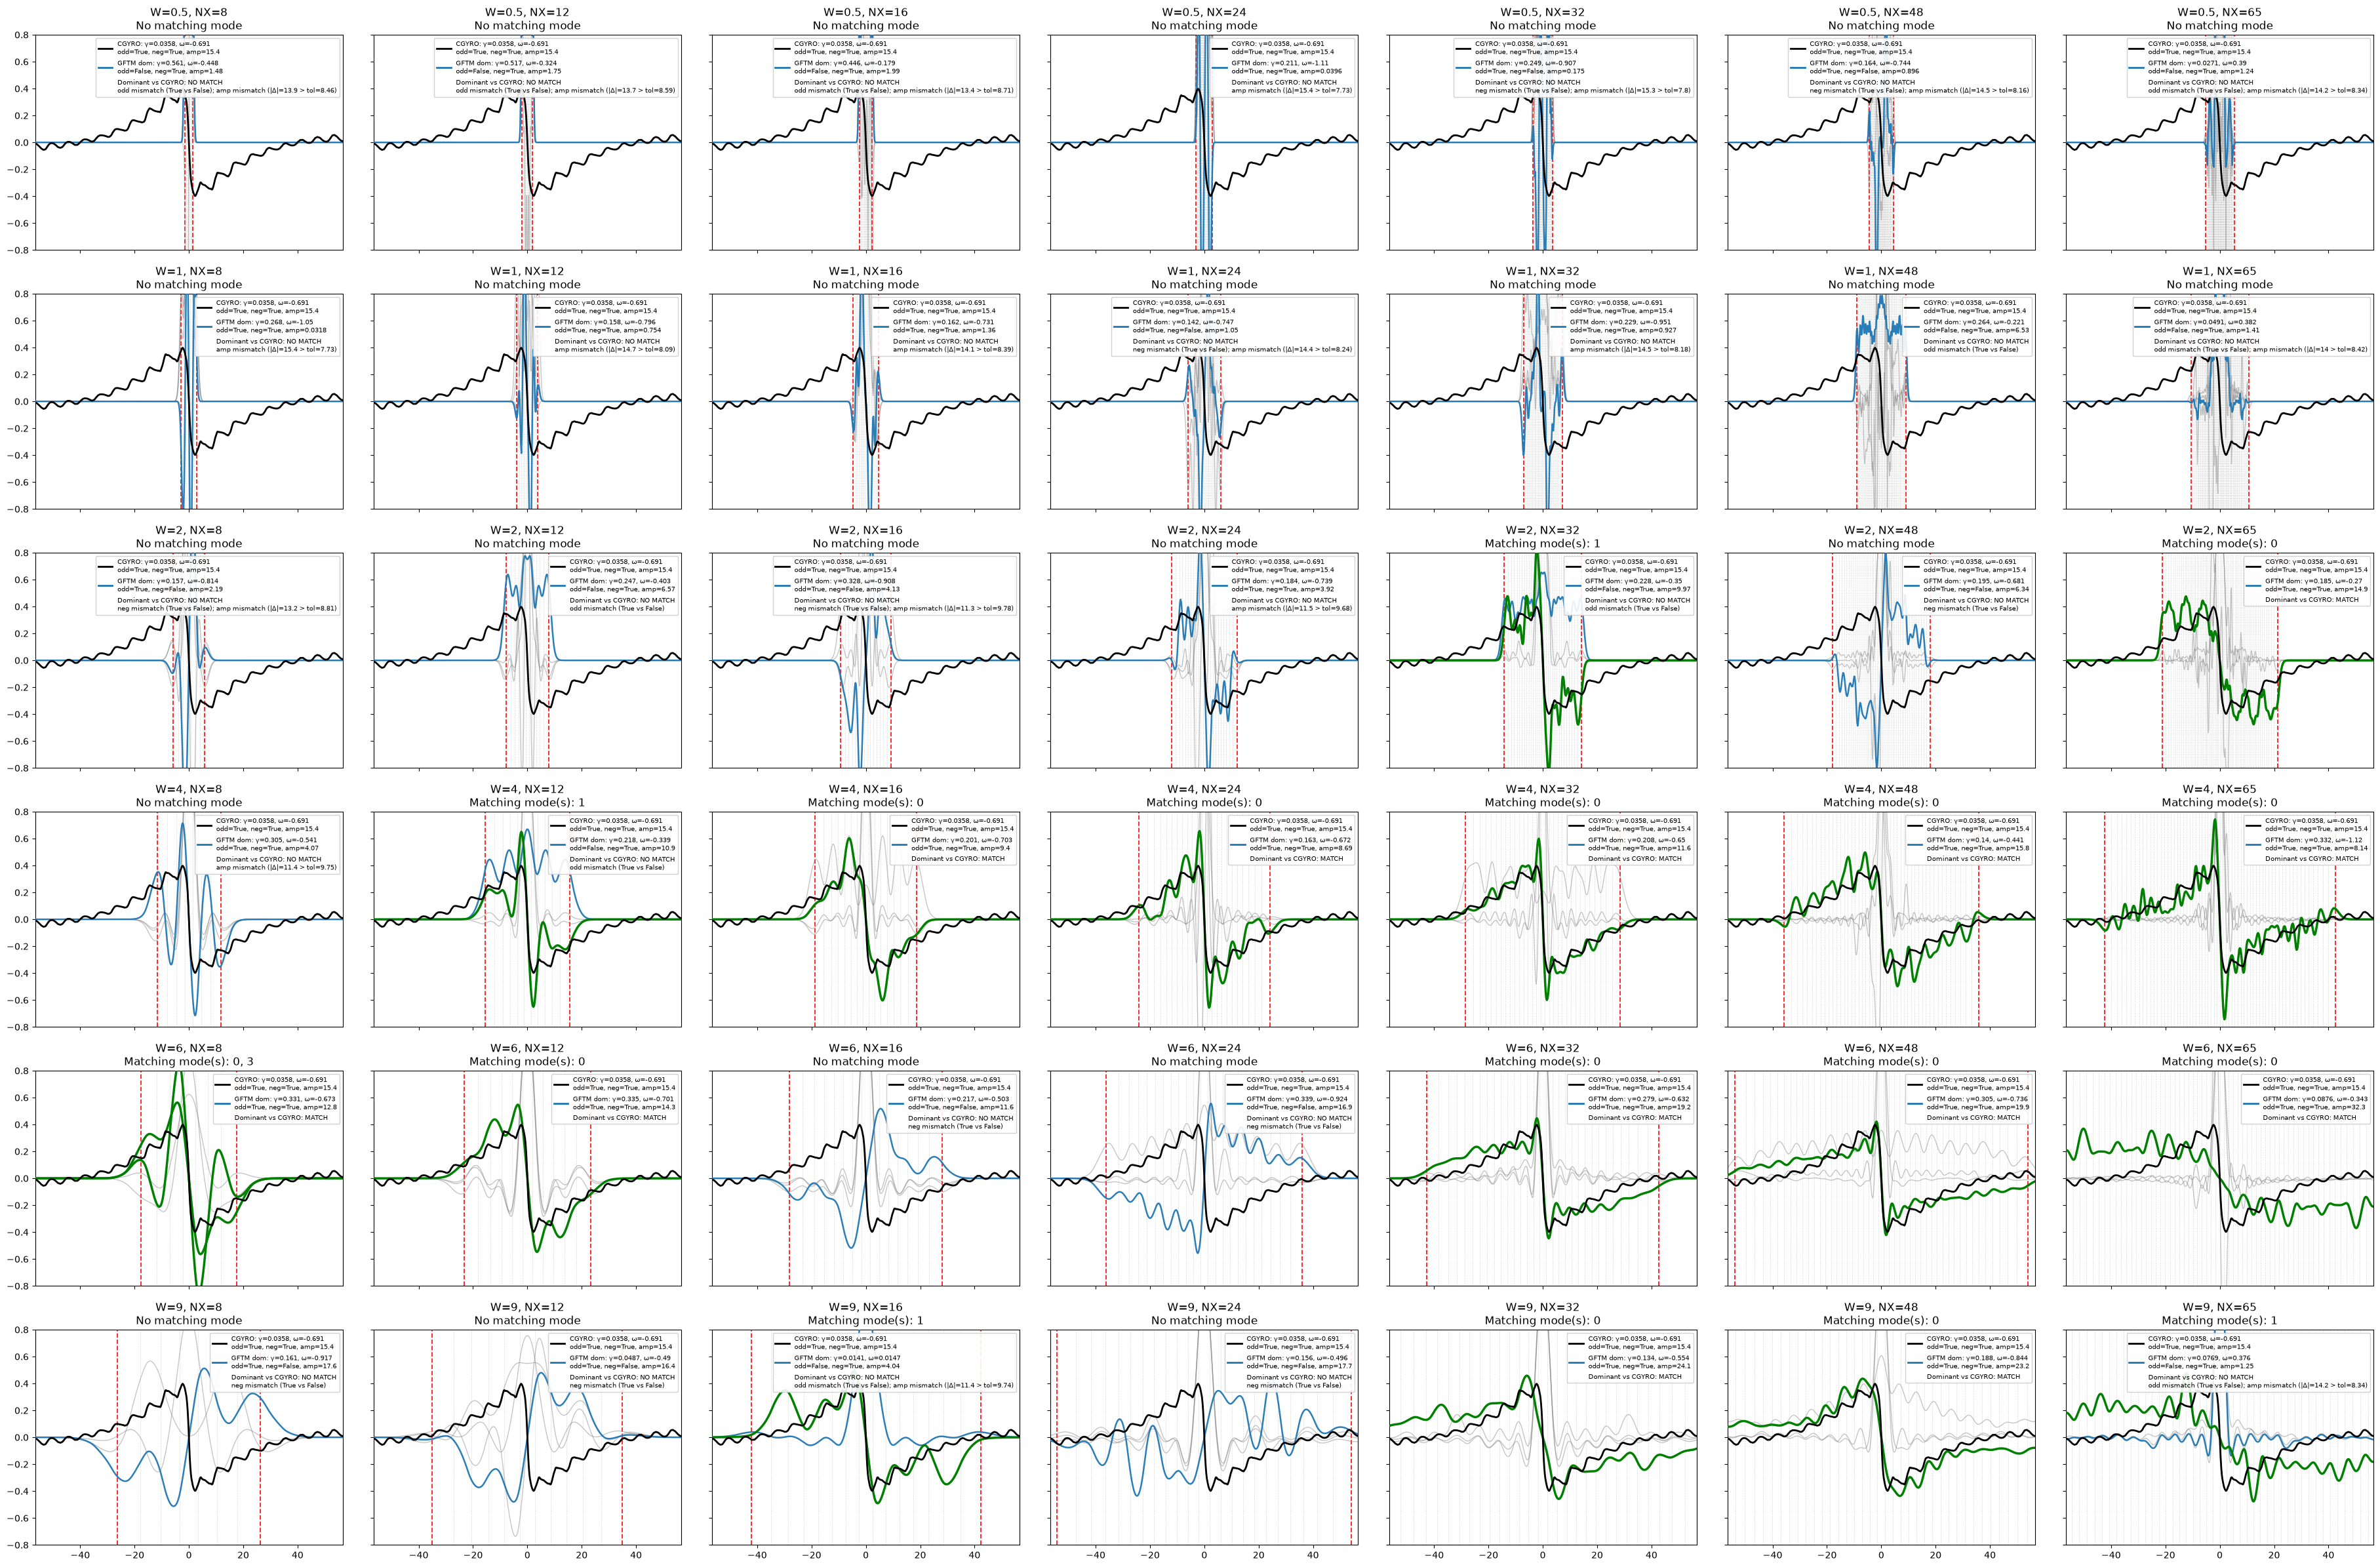

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite
from matplotlib.lines import Line2D


def to_float(x):
    """
    Convert plain scalars, numpy scalars, or pint quantities to float.
    """
    if hasattr(x, "item"):
        x = x.item()
    if hasattr(x, "magnitude"):
        return float(x.magnitude)
    return float(x)

def integrate_theta(da):
    """Integrate a one-dimensional DataArray over theta."""
    da = da.sortby("theta")

    return float(
        np.trapezoid(
            y=np.asarray(da.values),
            x=np.asarray(da.theta.values),
        )
    )


def calculate_eigenfunction_properties(
    da,
    theta_extent=18 * np.pi,
    normalize=True,
):
    da = (
        da
        .squeeze(drop=True)
        .sortby("theta")
        .where(np.abs(da.theta) <= theta_extent, drop=True)
    )

    if normalize:
        peak = to_float(np.abs(da).max())

        if peak == 0:
            raise ValueError("Cannot normalize a zero eigenfunction.")

        da = da / peak

    positive_theta = da.where(da.theta > 0, drop=True)
    negative_theta = da.where(da.theta < 0, drop=True)

    positive_integral = integrate_theta(positive_theta)
    negative_integral = integrate_theta(negative_theta)

    func_odd = positive_integral * negative_integral < 0

    neg = (
        (func_odd and positive_integral < 0)
        or
        ((not func_odd) and positive_integral > 0)
    )

    average_amplitude = (
        abs(positive_integral) + abs(negative_integral)
    ) / 2

    return {
        "odd": bool(func_odd),
        "neg": bool(neg),
        "avg_amp": float(average_amplitude),
        "pos_sum": float(positive_integral),
        "neg_sum": float(negative_integral),
    }


def compare_eigenfunctions(
    da1,
    da2,
    amp_fraction=0.5,
    theta_extent=18 * np.pi,
):
    props1 = calculate_eigenfunction_properties(
        da1,
        theta_extent=theta_extent,
    )
    props2 = calculate_eigenfunction_properties(
        da2,
        theta_extent=theta_extent,
    )

    reasons = []

    if props1["odd"] != props2["odd"]:
        reasons.append(
            f"odd mismatch ({props1['odd']} vs {props2['odd']})"
        )

    if props1["neg"] != props2["neg"]:
        reasons.append(
            f"neg mismatch ({props1['neg']} vs {props2['neg']})"
        )

    amp_diff = abs(
        props1["avg_amp"] - props2["avg_amp"]
    )

    amp_tol = amp_fraction * (
        props1["avg_amp"] + props2["avg_amp"]
    )

    if amp_diff > amp_tol:
        reasons.append(
            f"amp mismatch "
            f"(|Δ|={amp_diff:.3g} > tol={amp_tol:.3g})"
        )

    agrees = len(reasons) == 0

    return agrees, reasons, props1, props2


def gaussian_quadrature_points(width, nxgrid):
    nodes, weights = roots_hermite(int(nxgrid))
    theta_nodes = width * nodes
    return theta_nodes, weights


def get_last_scalar(da):
    """
    Reduce a DataArray to a scalar float.
    If there is a time dimension, take the final time point.
    """
    if "time" in da.dims:
        da = da.isel(time=-1)
    return to_float(da.squeeze(drop=True))


# ------------------------------------------------------------------
# Data selection
# ------------------------------------------------------------------
case = "p3_mtm17"
gftm_pyroscan = gftm_dict[case]
cgyro_pyro = cgyro_dict[case]

eigenfunctions = gftm_pyroscan.gk_output["eigenfunctions"]

# GFTM growth rate / frequency arrays
gftm_growth = gftm_pyroscan.gk_output["growth_rate"]
gftm_freq = gftm_pyroscan.gk_output["mode_frequency"]

# CGYRO reference eigenfunction
cgyro_eigenfunction = np.real(
    cgyro_pyro.gk_output["eigenfunctions"]
    .sel(field="phi")
    .isel(time=-1)
    .squeeze(drop=True)
)

# CGYRO growth rate / frequency
cgyro_growth = get_last_scalar(cgyro_pyro.gk_output["growth_rate"])
cgyro_freq = get_last_scalar(cgyro_pyro.gk_output["mode_frequency"])

# Precompute CGYRO diagnostics
cgyro_props = calculate_eigenfunction_properties(cgyro_eigenfunction)

widths = eigenfunctions.coords["width"].values
nxgrids = eigenfunctions.coords["nxgrid"].values
mode_values = eigenfunctions.coords["mode"].values

fig, axes = plt.subplots(
    nrows=len(widths),
    ncols=len(nxgrids),
    figsize=(5.2 * len(nxgrids), 4.0 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

theta_min = -18 * np.pi
theta_max = 18 * np.pi

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):
        ax = axes[i, j]

        local_modes = np.real(
            eigenfunctions.sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
        )

        local_growth = gftm_growth.sel(width=width, nxgrid=nxgrid)
        local_freq = gftm_freq.sel(width=width, nxgrid=nxgrid)

        # Plot CGYRO reference
        cgyro_line, = ax.plot(
            cgyro_eigenfunction.theta,
            cgyro_eigenfunction,
            color="black",
            linewidth=2.0,
            zorder=5,
        )

        matching_modes = []

        dominant_phi = None
        dominant_gamma = None
        dominant_omega = None
        dominant_compare = None
        dominant_reasons = None
        dominant_props = None

        # Plot all GFTM modes
        for mode_index, mode_value in enumerate(mode_values):
            phi_gftm = (
                local_modes
                .isel(mode=mode_index)
                .squeeze(drop=True)
            )

            gamma_gftm = get_last_scalar(
                local_growth.isel(mode=mode_index)
            )
            omega_gftm = get_last_scalar(
                local_freq.isel(mode=mode_index)
            )

            agrees, reasons, _, gftm_props = compare_eigenfunctions(
                cgyro_eigenfunction,
                phi_gftm,
            )

            if agrees:
                matching_modes.append(mode_value)

                colour = "green"
                linewidth = 2.5
                alpha = 1.0
                zorder = 4

            elif mode_index == 0:
                colour = "C0"
                linewidth = 1.8
                alpha = 0.95
                zorder = 3

            else:
                colour = "grey"
                linewidth = 1.0
                alpha = 0.45
                zorder = 2

            ax.plot(
                phi_gftm.theta,
                phi_gftm,
                color=colour,
                linewidth=linewidth,
                alpha=alpha,
                zorder=zorder,
            )

            # Save dominant-mode diagnostics
            if mode_index == 0:
                dominant_phi = phi_gftm
                dominant_gamma = gamma_gftm
                dominant_omega = omega_gftm
                dominant_compare = agrees
                dominant_reasons = reasons
                dominant_props = gftm_props

        # Quadrature nodes
        theta_nodes, quadrature_weights = gaussian_quadrature_points(
            width=width,
            nxgrid=nxgrid,
        )

        # Interior nodes
        for theta_node in theta_nodes[1:-1]:
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="grey",
                    linestyle=":",
                    linewidth=0.7,
                    alpha=0.35,
                    zorder=0,
                )

        # Outermost nodes
        for theta_node in (theta_nodes[0], theta_nodes[-1]):
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="red",
                    linestyle="--",
                    linewidth=1.3,
                    alpha=0.9,
                    zorder=1,
                )

        # Title
        if matching_modes:
            matched_text = ", ".join(str(m) for m in matching_modes)
            title_text = f"W={width:g}, NX={int(nxgrid)}\nMatching mode(s): {matched_text}"
        else:
            title_text = f"W={width:g}, NX={int(nxgrid)}\nNo matching mode"

        ax.set_title(title_text)

        # ------------------------------------------------------------------
        # Per-subplot legend with diagnostics
        # ------------------------------------------------------------------

        if dominant_compare:
            compare_text = "Dominant vs CGYRO: MATCH"
        else:
            compare_text = (
                "Dominant vs CGYRO: NO MATCH\n"
                + "; ".join(dominant_reasons)
            )

        cgyro_label = (
            f"CGYRO: γ={cgyro_growth:.3g}, ω={cgyro_freq:.3g}\n"
            f"odd={cgyro_props['odd']}, neg={cgyro_props['neg']}, "
            f"amp={cgyro_props['avg_amp']:.3g}"
        )

        dominant_label = (
            f"GFTM dom: γ={dominant_gamma:.3g}, ω={dominant_omega:.3g}\n"
            f"odd={dominant_props['odd']}, neg={dominant_props['neg']}, "
            f"amp={dominant_props['avg_amp']:.3g}"
        )

        extra_handles = [
            cgyro_line,
            Line2D([0], [0], color="C0", lw=2),
            Line2D([0], [0], color="none"),
        ]
        extra_labels = [
            cgyro_label,
            dominant_label,
            compare_text,
        ]

        ax.legend(
            extra_handles,
            extra_labels,
            loc="upper right",
            fontsize=7,
            framealpha=0.9,
            handlelength=2.2,
        )

        ax.set_xlim(theta_min, theta_max)
        ax.set_ylim(-0.8, 0.8)

        if i < len(widths) - 1:
            ax.set_xlabel("")

        if j > 0:
            ax.set_ylabel("")

fig.tight_layout()
#plt.savefig(f"eigenfunction_comparison_{case}.png", dpi=600, bbox_inches="tight")
plt.show()

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Proje

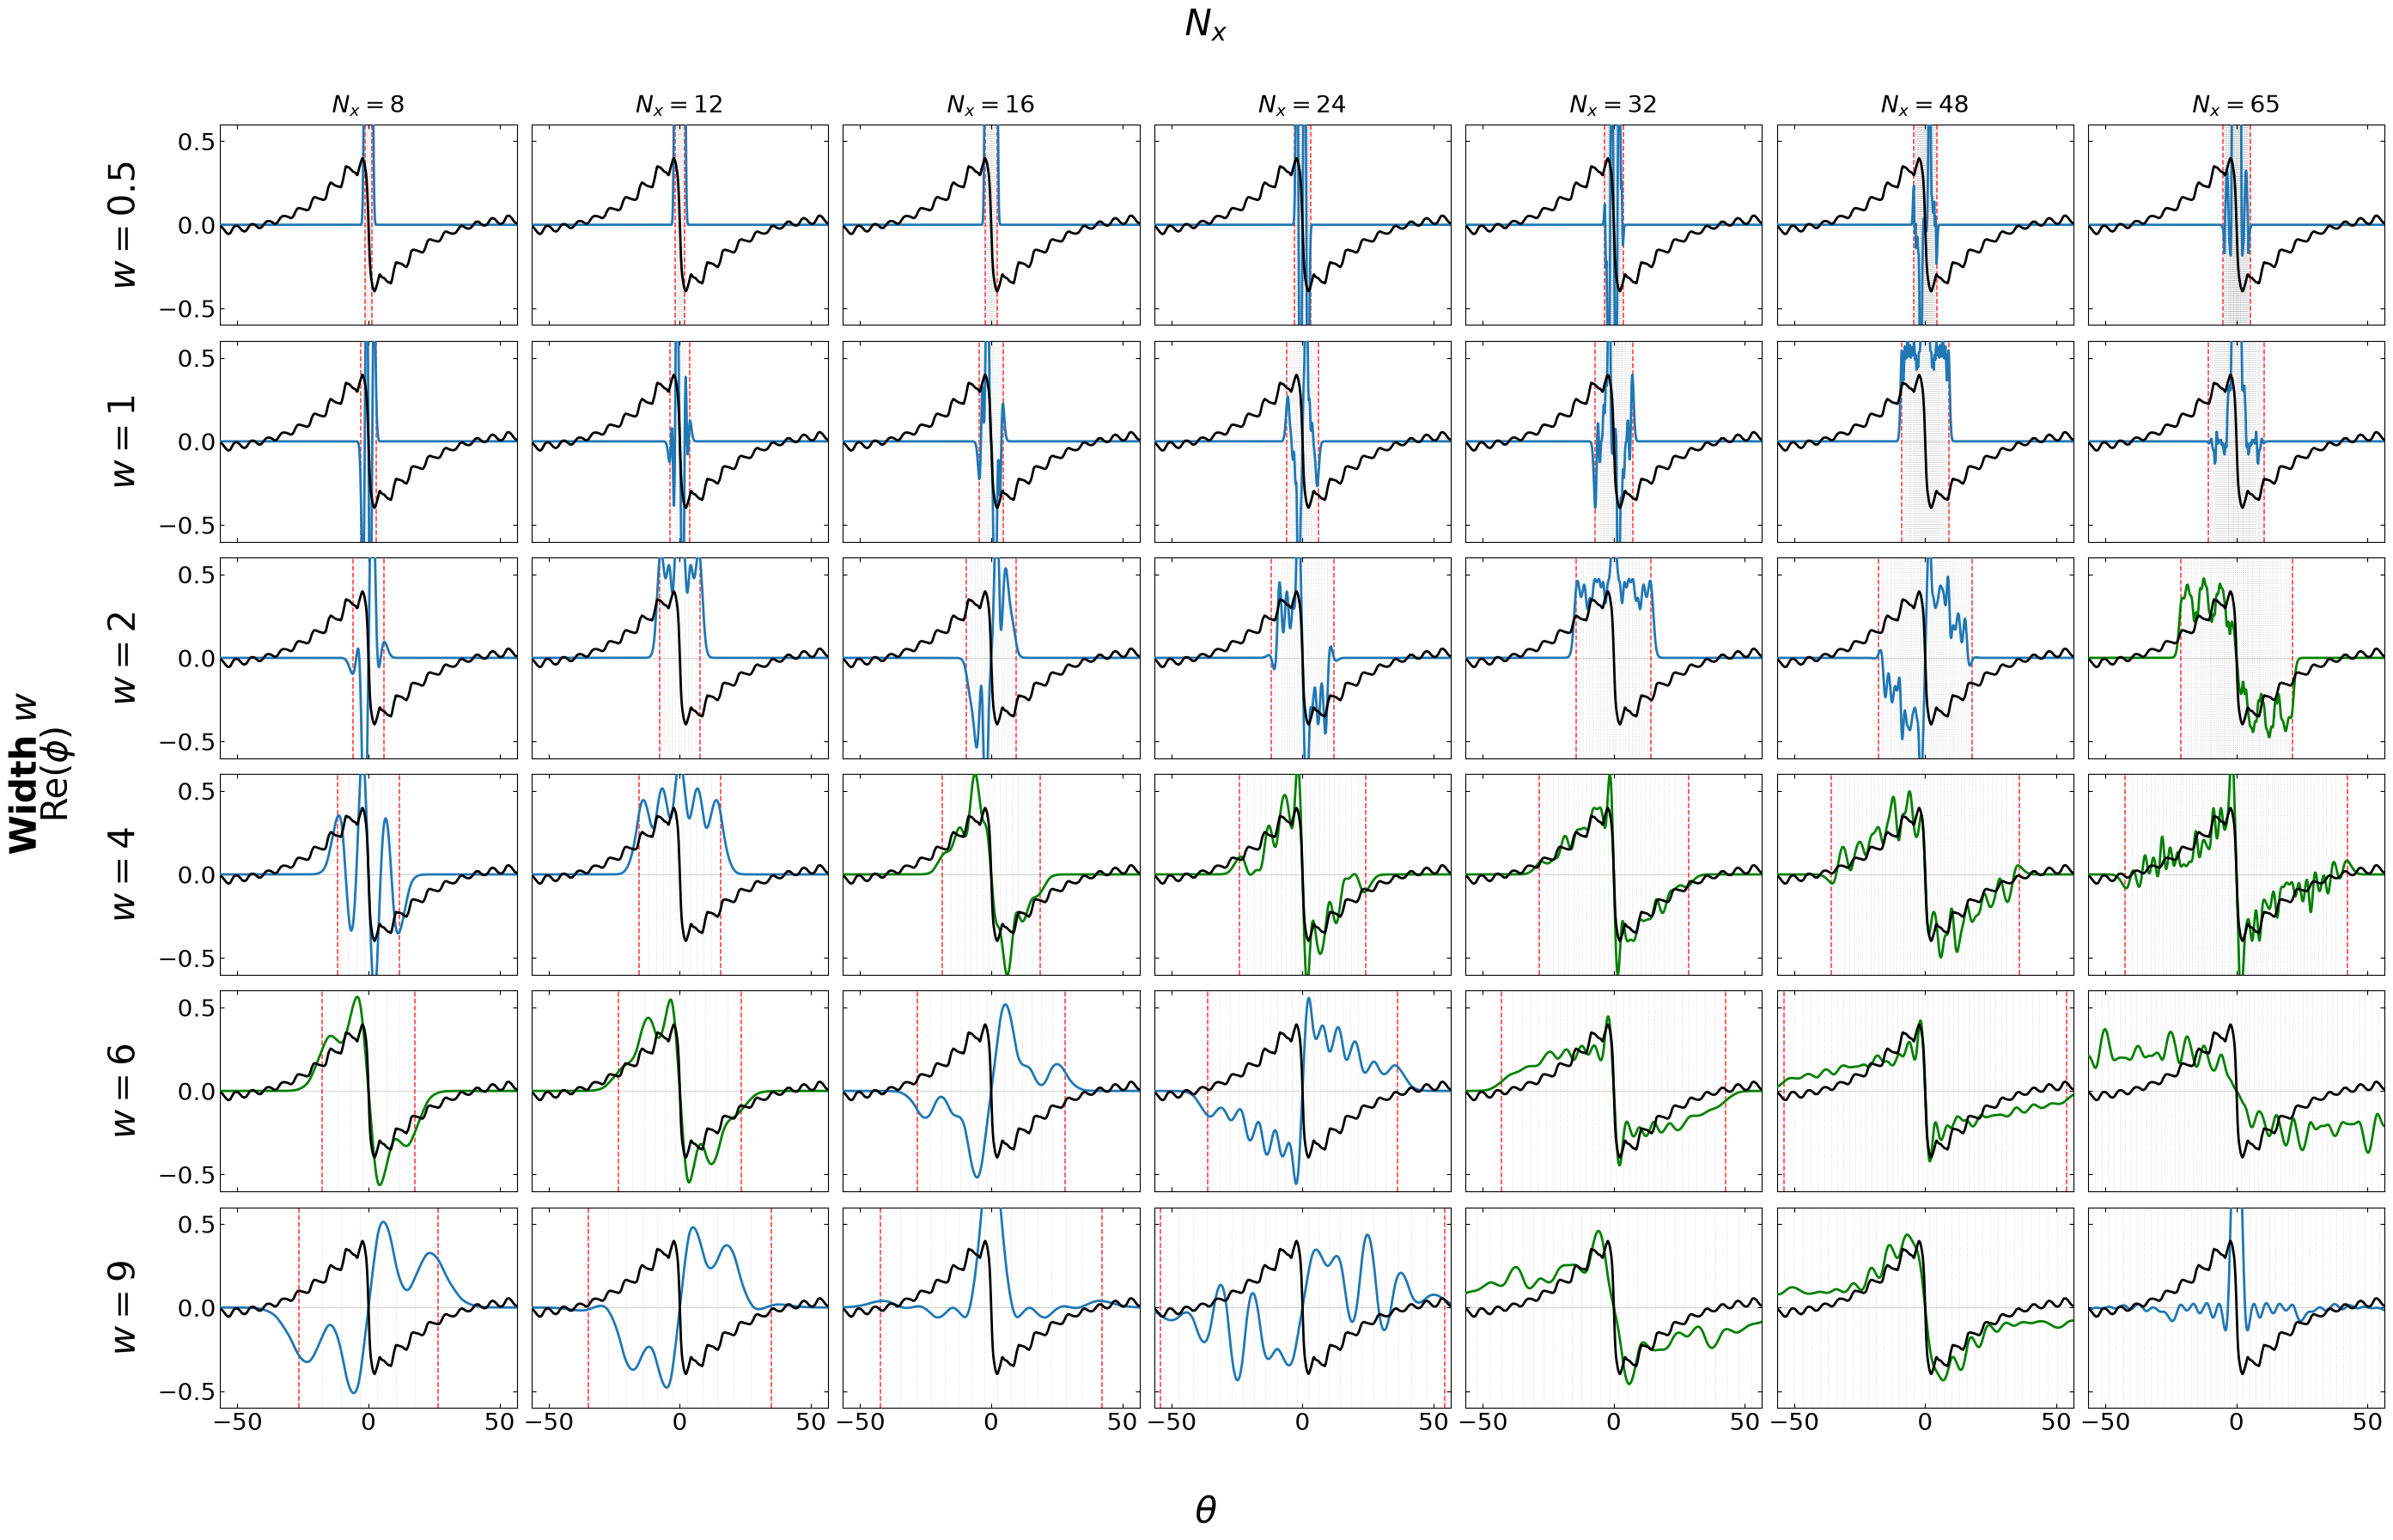

In [14]:
# ------------------------------------------------------------------
# Simplified dominant-mode comparison plot
# ------------------------------------------------------------------

widths = eigenfunctions.coords["width"].values
nxgrids = eigenfunctions.coords["nxgrid"].values

fig, axes = plt.subplots(
    nrows=len(widths),
    ncols=len(nxgrids),
    figsize=(4.0 * len(nxgrids), 3.0 * len(widths)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

theta_min = -18 * np.pi
theta_max = 18 * np.pi

for i, width in enumerate(widths):
    for j, nxgrid in enumerate(nxgrids):
        ax = axes[i, j]

        # Dominant GFTM eigenfunction only
        dominant_phi = np.real(
            eigenfunctions
            .sel(
                width=width,
                nxgrid=nxgrid,
                field="phi",
            )
            .isel(mode=0)
            .squeeze(drop=True)
        )

        agrees, _, _, _ = compare_eigenfunctions(
            cgyro_eigenfunction,
            dominant_phi,
        )

        # CGYRO reference
        ax.plot(
            cgyro_eigenfunction.theta,
            cgyro_eigenfunction,
            color="black",
            linewidth=2.0,
            zorder=4,
        )

        # Dominant GFTM mode
        ax.plot(
            dominant_phi.theta,
            dominant_phi,
            color="green" if agrees else "C0",
            linewidth=2.0,
            zorder=3,
        )

        # Gaussian quadrature nodes
        theta_nodes, _ = gaussian_quadrature_points(
            width=width,
            nxgrid=nxgrid,
        )

        # Interior quadrature nodes
        for theta_node in theta_nodes[1:-1]:
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="grey",
                    linestyle=":",
                    linewidth=0.7,
                    alpha=0.3,
                    zorder=0,
                )

        # Outermost quadrature nodes
        for theta_node in (theta_nodes[0], theta_nodes[-1]):
            if theta_min <= theta_node <= theta_max:
                ax.axvline(
                    theta_node,
                    color="red",
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.8,
                    zorder=1,
                )

        ax.axhline(
            0.0,
            color="grey",
            linewidth=0.6,
            alpha=0.4,
            zorder=0,
        )

        ax.set_xlim(theta_min, theta_max)
        ax.set_ylim(-0.6, 0.6)

        # Column-level nxgrid labels
        if i == 0:
            ax.set_title(
                rf"$N_{{x}} = {int(nxgrid)}$",
                fontsize=20,
                pad=10,
            )

        # Row-level width labels
        if j == 0:
            ax.set_ylabel(
                rf"$w = {to_float(width):g}$",
                fontsize=30,
                rotation=90,
                labelpad=12,
            )

        ax.tick_params(
            direction="in",
            top=True,
            right=True,
            labelsize=20
        )

# Shared physical axes
fig.supxlabel(r"$\theta$", fontsize=30)
fig.supylabel(r"$\mathrm{Re}(\phi)$", fontsize=30, x=0.015)

# Labels identifying the two parameter dimensions
fig.text(
    0.5,
    0.995,
    r"$N_x$",
    ha="center",
    va="top",
    fontsize=30,
    fontweight="bold",
)

fig.text(
    0.002,
    0.5,
    r"Width $w$",
    ha="left",
    va="center",
    rotation=90,
    fontsize=30,
    fontweight="bold",
)

fig.subplots_adjust(
    left=0.09,
    right=0.99,
    bottom=0.09,
    top=0.92,
    wspace=0.05,
    hspace=0.08,
)

plt.savefig(
    f"eigenfunction_comparison_{case}.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

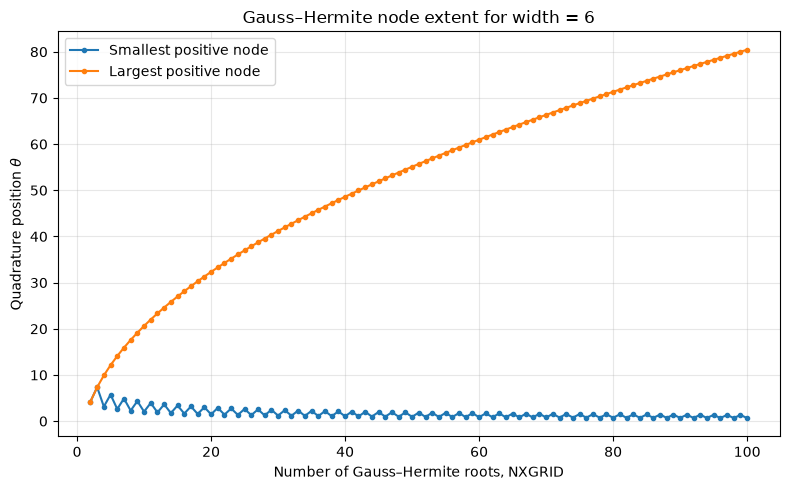

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite


def positive_quadrature_extents(nxgrid_values, width=1.0):
    nxgrid_values = np.asarray(nxgrid_values, dtype=int)

    minimum_positive_nodes = []
    maximum_positive_nodes = []

    for nxgrid in nxgrid_values:
        dimensionless_nodes, _ = roots_hermite(nxgrid)

        # Convert from dimensionless Hermite coordinates to theta
        theta_nodes = width * dimensionless_nodes

        # Exclude zero for odd nxgrid
        positive_nodes = theta_nodes[theta_nodes > 0]

        if positive_nodes.size == 0:
            minimum_positive_nodes.append(np.nan)
            maximum_positive_nodes.append(np.nan)
        else:
            minimum_positive_nodes.append(positive_nodes.min())
            maximum_positive_nodes.append(positive_nodes.max())

    return (
        nxgrid_values,
        np.asarray(minimum_positive_nodes),
        np.asarray(maximum_positive_nodes),
    )


# Number of quadrature roots to examine
nxgrid_values = np.arange(2, 101)

# Choose the GFTM Gaussian width
width = 6.0

(
    nxgrid_values,
    minimum_positive_nodes,
    maximum_positive_nodes,
) = positive_quadrature_extents(
    nxgrid_values,
    width=width,
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nxgrid_values,
    minimum_positive_nodes,
    marker=".",
    label="Smallest positive node",
)

ax.plot(
    nxgrid_values,
    maximum_positive_nodes,
    marker=".",
    label="Largest positive node",
)

ax.set_xlabel("Number of Gauss–Hermite roots, NXGRID")
ax.set_ylabel(r"Quadrature position $\theta$")
ax.set_title(f"Gauss–Hermite node extent for width = {width:g}")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite


def positive_quadrature_extents(nxgrid_values, width=1.0):
    nxgrid_values = np.asarray(nxgrid_values, dtype=int)

    minimum_positive_nodes = []
    maximum_positive_nodes = []

    for nxgrid in nxgrid_values:
        nodes, _ = roots_hermite(nxgrid)
        theta_nodes = width * nodes

        positive_nodes = theta_nodes[theta_nodes > 0]

        minimum_positive_nodes.append(positive_nodes.min())
        maximum_positive_nodes.append(positive_nodes.max())

    return (
        nxgrid_values,
        np.asarray(minimum_positive_nodes),
        np.asarray(maximum_positive_nodes),
    )


# Only fit NXGRID values from 16 to 64 inclusive
nxgrid_values = np.arange(1, 65)

width = 6.0

(
    nxgrid_values,
    minimum_positive_nodes,
    maximum_positive_nodes,
) = positive_quadrature_extents(
    nxgrid_values,
    width=width,
)

# Convert positions to units of pi
minimum_positive_pi = minimum_positive_nodes / np.pi
maximum_positive_pi = maximum_positive_nodes / np.pi

# Linear fits over NXGRID = 16,...,64
minimum_coefficients = np.polyfit(
    nxgrid_values,
    minimum_positive_pi,
    deg=1,
)

maximum_coefficients = np.polyfit(
    nxgrid_values,
    maximum_positive_pi,
    deg=1,
)

minimum_slope, minimum_intercept = minimum_coefficients
maximum_slope, maximum_intercept = maximum_coefficients

minimum_fit = np.polyval(
    minimum_coefficients,
    nxgrid_values,
)

maximum_fit = np.polyval(
    maximum_coefficients,
    nxgrid_values,
)


def r_squared(y, y_fit):
    residual_sum_squares = np.sum((y - y_fit) ** 2)
    total_sum_squares = np.sum((y - np.mean(y)) ** 2)

    return 1 - residual_sum_squares / total_sum_squares


minimum_r2 = r_squared(
    minimum_positive_pi,
    minimum_fit,
)

maximum_r2 = r_squared(
    maximum_positive_pi,
    maximum_fit,
)


fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    nxgrid_values,
    minimum_positive_pi,
    marker=".",
    linestyle="none",
    label="Smallest positive node",
)

ax.plot(
    nxgrid_values,
    maximum_positive_pi,
    marker=".",
    linestyle="none",
    label="Largest positive node",
)

ax.plot(
    nxgrid_values,
    minimum_fit,
    linestyle="--",
    label=(
        r"Minimum fit: "
        rf"$\theta_{{\min}}/\pi="
        rf"{minimum_slope:.5f}N"
        rf"{minimum_intercept:+.5f}$, "
        rf"$R^2={minimum_r2:.4f}$"
    ),
)

ax.plot(
    nxgrid_values,
    maximum_fit,
    linestyle="--",
    label=(
        r"Maximum fit: "
        rf"$\theta_{{\max}}/\pi="
        rf"{maximum_slope:.5f}N"
        rf"{maximum_intercept:+.5f}$, "
        rf"$R^2={maximum_r2:.4f}$"
    ),
)

ax.axhline(
    18,
    linestyle=":",
    label=r"$18\pi$ extent",
)

ax.set_xlim(0, 64)
ax.set_xlabel("Number of Gauss–Hermite roots, $N$")
ax.set_ylabel(r"Quadrature position, $\theta/\pi$")
ax.set_title(
    f"Gauss–Hermite node positions for "
    f"$16 \\leq N \\leq 64$, width = {width:g}"
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

print(
    "Smallest positive node:"
    f" theta_min/pi = {minimum_slope:.8f} N"
    f" {minimum_intercept:+.8f},"
    f" R² = {minimum_r2:.6f}"
)

print(
    "Largest positive node:"
    f" theta_max/pi = {maximum_slope:.8f} N"
    f" {maximum_intercept:+.8f},"
    f" R² = {maximum_r2:.6f}"
)

ValueError: zero-size array to reduction operation minimum which has no identity

In [33]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import roots_hermite


def positive_quadrature_extents(nxgrid_values, width=1.0):
    nxgrid_values = np.asarray(nxgrid_values, dtype=int)

    minimum_positive_nodes = []
    maximum_positive_nodes = []

    for nxgrid in nxgrid_values:
        nodes, _ = roots_hermite(nxgrid)
        theta_nodes = width * nodes

        positive_nodes = theta_nodes[theta_nodes > 0]

        # N=1 has its only node at theta=0, so there is no positive node.
        if positive_nodes.size == 0:
            minimum_positive_nodes.append(np.nan)
            maximum_positive_nodes.append(np.nan)
        else:
            minimum_positive_nodes.append(positive_nodes.min())
            maximum_positive_nodes.append(positive_nodes.max())

    return (
        nxgrid_values,
        np.asarray(minimum_positive_nodes),
        np.asarray(maximum_positive_nodes),
    )


# Plot the full range down to the origin ...
nxgrid_values = np.arange(1, 65)

# ... but fit only the high-N window, so the extrapolation to low N is a
# genuine prediction and its breakdown is visible.
fit_min_n, fit_max_n = 16, 64

width = 1.0

(
    nxgrid_values,
    minimum_positive_nodes,
    maximum_positive_nodes,
) = positive_quadrature_extents(
    nxgrid_values,
    width=width,
)

minimum_positive_pi = minimum_positive_nodes / np.pi
maximum_positive_pi = maximum_positive_nodes / np.pi

fit_mask = (nxgrid_values >= fit_min_n) & (nxgrid_values <= fit_max_n)

minimum_coefficients = np.polyfit(
    nxgrid_values[fit_mask],
    minimum_positive_pi[fit_mask],
    deg=1,
)

maximum_coefficients = np.polyfit(
    nxgrid_values[fit_mask],
    maximum_positive_pi[fit_mask],
    deg=1,
)

minimum_slope, minimum_intercept = minimum_coefficients
maximum_slope, maximum_intercept = maximum_coefficients

# Evaluate the fits across the WHOLE range, including where they were not fitted.
minimum_fit = np.polyval(minimum_coefficients, nxgrid_values)
maximum_fit = np.polyval(maximum_coefficients, nxgrid_values)


def r_squared(y, y_fit):
    residual_sum_squares = np.sum((y - y_fit) ** 2)
    total_sum_squares = np.sum((y - np.mean(y)) ** 2)

    return 1 - residual_sum_squares / total_sum_squares


# R^2 quoted over the fit window only.
minimum_r2 = r_squared(minimum_positive_pi[fit_mask], minimum_fit[fit_mask])
maximum_r2 = r_squared(maximum_positive_pi[fit_mask], maximum_fit[fit_mask])


fig, ax = plt.subplots(figsize=(9, 6))

ax.axvspan(
    fit_min_n,
    fit_max_n,
    color="0.92",
    zorder=0,
    label=rf"Fit window ${fit_min_n} \leq N \leq {fit_max_n}$",
)

ax.plot(
    nxgrid_values,
    minimum_positive_pi,
    marker=".",
    linestyle="none",
    label="Smallest positive node",
)

ax.plot(
    nxgrid_values,
    maximum_positive_pi,
    marker=".",
    linestyle="none",
    label="Largest positive node",
)

ax.plot(
    nxgrid_values,
    minimum_fit,
    linestyle="--",
    label=(
        r"Minimum fit"
    ),
)

ax.plot(
    nxgrid_values,
    maximum_fit,
    linestyle="--",
    label=(
        r"Maximum fit"
    ),
)


ax.set_xlim(0, 64)
ax.set_ylim(0,3.5)
ax.set_xlabel("Number of Gauss–Hermite roots, $N$")
ax.set_ylabel(r"Quadrature position, $\theta/\pi$")
ax.set_title(
    f"Gauss–Hermite node positions"
)

ax.grid(alpha=0.3)
ax.legend(loc="upper left", framealpha=0.95, fontsize=9)

fig.tight_layout()
fig.savefig("nodes_plot.png", dpi=110)

print(
    "Smallest positive node:"
    f" theta_min/pi = {minimum_slope:.8f} N"
    f" {minimum_intercept:+.8f},"
    f" R² = {minimum_r2:.6f}"
)

print(
    "Largest positive node:"
    f" theta_max/pi = {maximum_slope:.8f} N"
    f" {maximum_intercept:+.8f},"
    f" R² = {maximum_r2:.6f}"
)

# How badly the high-N fit does when extrapolated below the fit window.
low = nxgrid_values < fit_min_n
resid = maximum_positive_pi[low] - maximum_fit[low]
print("\nExtrapolation error of the maximum fit below the window:")
for n, actual, pred in zip(nxgrid_values[low][:8], maximum_positive_pi[low][:8], maximum_fit[low][:8]):
    print(f"  N={n:2d}  actual={actual:7.3f}  fit={pred:7.3f}  error={pred-actual:+7.3f}")
print(f"  worst over N<{fit_min_n}: {np.nanmax(np.abs(resid)):.3f} in theta/pi")

Smallest positive node: theta_min/pi = -0.00118209 N +0.13456115, R² = 0.237021
Largest positive node: theta_max/pi = 0.03784915 N +1.01253818, R² = 0.991879

Extrapolation error of the maximum fit below the window:
  N= 1  actual=    nan  fit=  1.050  error=   +nan
  N= 2  actual=  0.225  fit=  1.088  error= +0.863
  N= 3  actual=  0.390  fit=  1.126  error= +0.736
  N= 4  actual=  0.525  fit=  1.164  error= +0.639
  N= 5  actual=  0.643  fit=  1.202  error= +0.559
  N= 6  actual=  0.748  fit=  1.240  error= +0.491
  N= 7  actual=  0.844  fit=  1.277  error= +0.433
  N= 8  actual=  0.933  fit=  1.315  error= +0.382
  worst over N<16: 0.863 in theta/pi


In [17]:
theta_min, theta_max = 0.3 * np.pi, 18 * np.pi
a_min, b_min, a_max, b_max = -0.00255006, 0.28663961, 0.11908146, 3.16691615

R = theta_max / theta_min
nxgrid = round((b_max - R * b_min) / (R * a_min - a_max))
width = theta_min / (a_min * nxgrid + b_min)

print(nxgrid, width)

52 6.118535913645773
